**NOTE:** Some variable names differ from those used in the main text, 
reflecting terminology changes made during the course of the study:
- 'fold' -> 'lineage'
- 'NONE' -> 'base seed'
- 'ALL' -> 'full network'

Each enzyme-gated network expansion run records iterations of network expansion as follows:
- cumiter: Tracks all individual expansion steps, including both lineage addition steps and the resulting standard network expansion steps
- folditer: Groups each lineage addition and the subsequent network expansion into a single unit; corresponds to a metabolic stage

In [1]:
from utils import*

In [2]:
# NONE 1000 runs

# df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/folds_folditer_NONE.csv', index_col=0)
# df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_folditer_NONE.csv', index_col=0)
# df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rns_folditer_NONE.csv', index_col=0)
# df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rules_folditer_NONE.csv', index_col=0)

# preATP 1000 runs

df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)
df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_folditer_preATP.csv', index_col=0)
df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_folditer_preATP.csv', index_col=0)

In [3]:
rns_scope = list(df_rns_folditer.index)
cpds_scope = list(df_cpds_folditer.index)
rn2rules_scope = {k:v for k,v in rn2rules.items() if k in rns_scope}
len(rn2rules_scope)

5730

# Figure S1/2

In [4]:
x2class['304'], x2class['7560']

('a+b', 'a/b')

In [5]:
rn2rules_scope

{'R01015': {frozenset({'2002'})},
 'R01061': {frozenset({'2003', '298'})},
 'R01063': {frozenset({'2003', '298'})},
 'R02189': {frozenset({'2484'})},
 'R01827': {frozenset({'2002'})},
 'R02736': {frozenset({'2003', '298'})},
 'R10907': {frozenset({'2003'}), frozenset({'2003', '298'})},
 'R01056': {frozenset({'7560'}), frozenset({'2003', '304'})},
 'R10221': {frozenset({'129', '2003'})},
 'R01528': {frozenset({'129', '2003'})},
 'R02035': {frozenset({'2003'}), frozenset({'2003', '298'}), frozenset({'5'})},
 'R05605': {frozenset({'2002'})},
 'R00342': {frozenset({'2003', '279'})},
 'R00705': {frozenset({'7524'})},
 'R03158': {frozenset({'2486'})},
 'R01608': {frozenset({'129', '2003'})},
 'R00706': {frozenset({'7524'})},
 'R00286': {frozenset({'129', '2003'})},
 'R02640': {frozenset({'2003'})},
 'R01478': {frozenset({'2002'}), frozenset({'11', '2002'})},
 'R01904': {frozenset({'2003'})},
 'R03313': {frozenset({'7524'}), frozenset({'7524', '7531'})},
 'R01251': {frozenset({'129', '2003'})

In [6]:
def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts', ylog=False, xlog=False, savefig=False):
    plt.figure(figsize=(2, 4))
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor=None)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)

    if ylog:
        plt.yscale('log', nonpositive='clip')
    if xlog:
        plt.xscale('log', nonpositive='clip')
    
    if savefig:
        plt.savefig(f'histo_{x_axis}.svg', dpi=300, bbox_inches='tight')
    
    plt.show()

## rule count per reaction

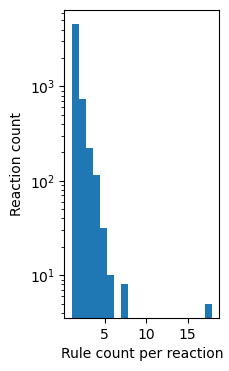

In [7]:
rn2rules_scopeNum = {k:len(v) for k,v in rn2rules_scope.items()}
histogram(rn2rules_scopeNum, bins=20, x_axis='Rule count per reaction', y_axis = 'Reaction count', ylog=True)

In [8]:
{k:v for k,v in rn2rules_scopeNum.items() if v > 5}

{'R00548_v1': 7,
 'R00164_v3': 18,
 'R00256_v2': 6,
 'R00164_v4': 18,
 'R00434_v3': 6,
 'R00434_v2': 6,
 'R00164_v5': 18,
 'R00434_v1': 6,
 'R00164_v2': 18,
 'R01010_v1': 7,
 'R01010_v2': 7,
 'R01313_v1': 6,
 'R00256_v1': 6,
 'R01315_v1': 6,
 'R01010_v3': 7,
 'R01010_v4': 7,
 'R00164_v1': 18,
 'R02053_v1': 6,
 'R07064_v1': 6,
 'R00548_v2': 7,
 'R07859_v1': 6,
 'R00548_v3': 7,
 'R00548_v4': 7}

In [9]:
"""
R00164:{{X2007},
{X3371},
{X2006, X221},
{X2},
{X109, X246},
{X2006, X7568},
{X210},
{X7525},
{X108, X246},
{X210, X246},
{X2006, X330},
{X101, X210},
{X73},
{X11, X206},
{X207, X210},
{X2006},
{X11},
{X246}}
"""

'\nR00164:{{X2007},\n{X3371},\n{X2006, X221},\n{X2},\n{X109, X246},\n{X2006, X7568},\n{X210},\n{X7525},\n{X108, X246},\n{X210, X246},\n{X2006, X330},\n{X101, X210},\n{X73},\n{X11, X206},\n{X207, X210},\n{X2006},\n{X11},\n{X246}}\n'

In [10]:
rn2rules['R00164_v4']

{frozenset({'109', '246'}),
 frozenset({'108', '246'}),
 frozenset({'7525'}),
 frozenset({'3371'}),
 frozenset({'73'}),
 frozenset({'210', '246'}),
 frozenset({'2007'}),
 frozenset({'11'}),
 frozenset({'246'}),
 frozenset({'2006'}),
 frozenset({'207', '210'}),
 frozenset({'2006', '330'}),
 frozenset({'11', '206'}),
 frozenset({'2006', '7568'}),
 frozenset({'2'}),
 frozenset({'101', '210'}),
 frozenset({'2006', '221'}),
 frozenset({'210'})}

## reaction count per rule

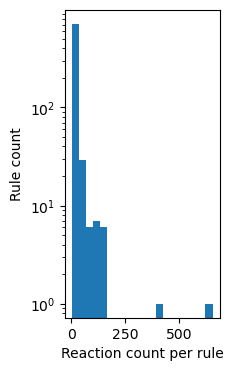

In [11]:
rule2rns = {}
for rn, rules in rn2rules_scope.items():
    for rule in rules:
        if rule not in rule2rns:
            rule2rns[rule] = [rn]
        else:
            rule2rns[rule].append(rn)
rule2rnsNum = {k:len(v) for k,v in rule2rns.items()}
histogram(rule2rnsNum, bins=20, x_axis='Reaction count per rule', y_axis = 'Rule count', ylog=True)

In [12]:
{k:v for k,v in rule2rnsNum.items() if v > 100}

{frozenset({'2002'}): 412,
 frozenset({'2484'}): 104,
 frozenset({'2003'}): 654,
 frozenset({'2007'}): 156,
 frozenset({'2006'}): 156,
 frozenset({'10'}): 144,
 frozenset({'149'}): 143,
 frozenset({'2004'}): 106,
 frozenset({'7512'}): 121,
 frozenset({'spontaneous'}): 113,
 frozenset({'3016', '7577'}): 154,
 frozenset({'141'}): 127,
 frozenset({'2003', '244'}): 113,
 frozenset({'109', '141'}): 152}

## rule count per lineage

396


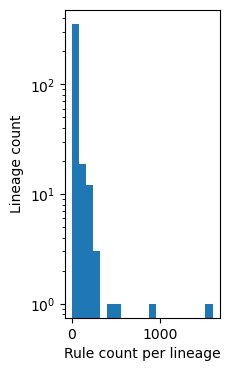

In [13]:
# how many (non-unique) rules does X appear in => counts rules, not reaction

x2rulesNum_scope = {}
for rn, rules in rn2rules_scope.items():
    for rule in rules:
        for x in rule:
            if x not in x2rulesNum_scope.keys():
                x2rulesNum_scope[x] = 1
            else:
                x2rulesNum_scope[x] += 1
x2rulesNum_scope.pop('spontaneous')
print(len(x2rulesNum_scope))
histogram(x2rulesNum_scope, bins=20, x_axis='Rule count per lineage', y_axis = 'Lineage count', ylog=True)

In [14]:
{k:v for k,v in x2rulesNum_scope.items() if v > 300}

{'2002': 926, '2003': 1593, '304': 443, '2007': 511}

7558 763
396


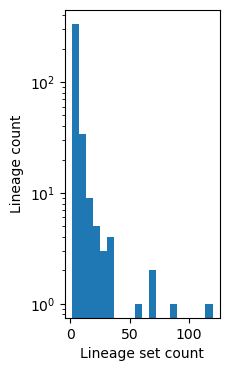

In [15]:
# how many UNIQUE rules does X appear in?
all_rules = []
for rn, rules in rn2rules_scope.items():
    for rule in rules:
        all_rules.append(rule)
print(len(all_rules), len(set(all_rules)))

x2rulesNum_scope = {}
for rule in set(all_rules):
    for x in rule:
        if x not in x2rulesNum_scope.keys():
            x2rulesNum_scope[x] = 1
        else:
            x2rulesNum_scope[x] += 1
x2rulesNum_scope.pop('spontaneous')
print(len(x2rulesNum_scope))
histogram(x2rulesNum_scope, bins=20, x_axis='Lineage set count', y_axis = 'Lineage count', ylog=True)

In [16]:
{k:v for k,v in x2rulesNum_scope.items() if v > 50}

{'2007': 69, '304': 71, '2002': 87, '2003': 120, '1': 58}

## lineage count per lineage set (n=763)

763


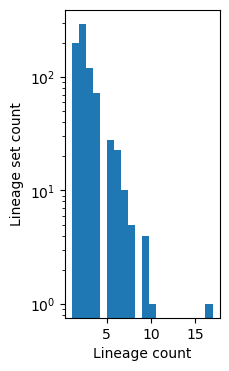

In [17]:
rule2len = {}
for rules in rn2rules_scope.values():
    for rule in rules:
        rule2len[rule] = len(rule)
print(len(rule2len))
histogram(rule2len, bins=20, x_axis='Lineage count', y_axis='Lineage set count', ylog=True)

In [18]:
{k:v for k,v in rule2len.items() if v >= 10}

{frozenset({'1001',
            '2003',
            '2007',
            '205',
            '221',
            '244',
            '2485',
            '3281',
            '3456',
            '3579',
            '3697',
            '3843',
            '4025',
            '4272',
            '4335',
            '5100',
            '633'}): 17,
 frozenset({'1',
            '1001',
            '2003',
            '205',
            '221',
            '2485',
            '3697',
            '4335',
            '5100',
            '633'}): 10}

In [19]:
rn2rules_scope['R11945_v1']

{frozenset({'3281', '3456', '3579', '3843'}),
 frozenset({'2007',
            '205',
            '244',
            '3281',
            '3456',
            '3579',
            '3843',
            '4025',
            '4272'}),
 frozenset({'1001',
            '2003',
            '2007',
            '205',
            '221',
            '244',
            '2485',
            '3281',
            '3456',
            '3579',
            '3697',
            '3843',
            '4025',
            '4272',
            '4335',
            '5100',
            '633'})}

## reaction count per lineage

In [20]:
x2rn_scope = {}
for rn, rules in rn2rules_scope.items():
    for rule in rules:
        for x in rule:
            if x not in x2rn_scope.keys():
                x2rn_scope[x] = [rn]
            else:
                x2rn_scope[x].append(rn)
x2rn_scope.pop('spontaneous')

x2rnNum_scope = {k:len(set(v)) for k,v in x2rn_scope.items()}
print(len(x2rnNum_scope))

396


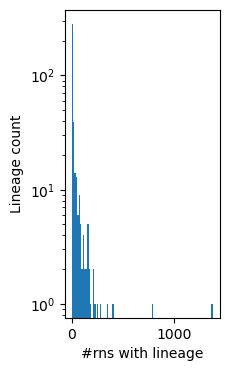

In [21]:
histogram(x2rnNum_scope, bins=100, x_axis='#rns with lineage', y_axis = 'Lineage count', ylog=True)

In [22]:
{k:v for k,v in x2rnNum_scope.items() if v >= 500}

{'2002': 789, '2003': 1380}

## lineage count per reaction

5730


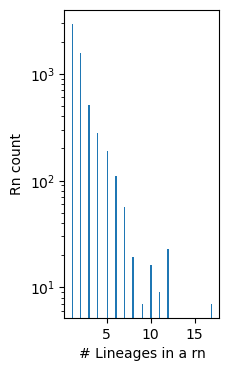

In [23]:
rn2folds = {}
for rn, rules in rn2rules_scope.items():
    folds = set()
    for rule in rules:
        folds.update(rule)
    rn2folds[rn] = len(folds)
print(len(rn2folds))
histogram(rn2folds, bins=100, x_axis='# Lineages in a rn', y_axis='Rn count', ylog=True)

In [24]:
{k:v for k,v in rn2folds.items() if v >= 17}

{'R00164_v3': 17,
 'R00164_v4': 17,
 'R11945_v1': 17,
 'R11945_v2': 17,
 'R00164_v5': 17,
 'R00164_v2': 17,
 'R00164_v1': 17}

# How many lineages till discovery of all cpds?

In [25]:
run2completion = {}
for run in df_cpds_folditer:
    folditer2folds = {}
    for fold, folditer in df_folds_folditer[run].items():
        if folditer not in folditer2folds.keys():
            folditer2folds[folditer] = [fold]
        else:
            folditer2folds[folditer].append(fold)
    
    # accumulate folds until completion
    folds_until_full_scope = []
    completion = max(df_cpds_folditer[run])
    for i, folds in folditer2folds.items():
        if i < completion and i > 2:  # also ignore 'fold_independent' and 'spontaneous'
            folds_until_full_scope.extend(folds)
    # add final fold(s)
    folds_until_full_scope.extend(folditer2folds[completion])
    
    run2completion[run] = folds_until_full_scope

In [26]:
run2completionNum = {k:len(v) for k,v in run2completion.items()}

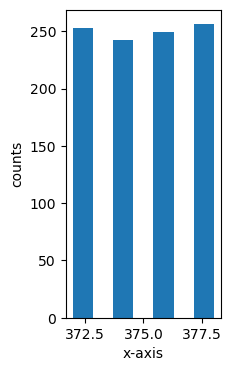

In [27]:
histogram(run2completionNum, bins = 7)

In [28]:
np.mean(list(run2completionNum.values())), np.std(list(run2completionNum.values()))  # 95%

(375.016, 2.2520532853376274)

## what about oxygen?

In [29]:
df_cpds_folditer[run]['C00007']

306

In [30]:
run2oxygen = {}
for run in df_cpds_folditer:
    folditer2folds = {}
    for fold, folditer in df_folds_folditer[run].items():
        if folditer not in folditer2folds.keys():
            folditer2folds[folditer] = [fold]
        else:
            folditer2folds[folditer].append(fold)
    
    # accumulate folds until completion
    folds_until_oxygen = []
    oxygen_iter = df_cpds_folditer[run]['C00007']
    for i, folds in folditer2folds.items():
        if i < oxygen_iter and i > 2:  # also ignore 'fold_independent' and 'spontaneous'
            folds_until_oxygen.extend(folds)
    # add final fold(s)
    folds_until_oxygen.extend(folditer2folds[oxygen_iter])
    
    run2oxygen[run] = folds_until_oxygen

314.754 6.855908692507509


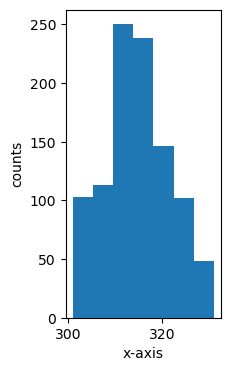

In [31]:
run2oxygenNum = {k:len(v) for k,v in run2oxygen.items()}
print(np.mean(list(run2oxygenNum.values())), np.std(list(run2oxygenNum.values())))  # 79%
histogram(run2oxygenNum, bins = 7)

# Does lineage-complexity of reactions increase over time?

## 1. per rule

In [32]:
# average of 1000 runs
rule2fo_ave = {index: np.mean(df_rules_folditer.loc[index]) for index in df_rules_folditer.index}

In [33]:
rule2numFolds = {}

for k in rule2fo_ave.keys():
    rule2numFolds[k] = len(eval(k)[1])

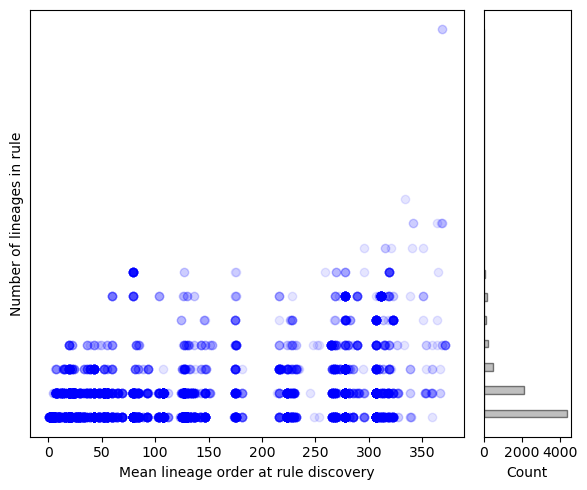

In [34]:
def scatterHisto(dict1, dict2, x_axis='x-axis', y_axis='y-axis'):
    # Prepare data
    valid_keys, data1, data2 = todata(dict1, dict2)
    
    # Create a grid layout for scatter plot and histogram
    fig = plt.figure(figsize=(6, 5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 0.4])  # 1 row, 2 columns, [first col, second col]

    # Scatter plot
    ax_scatter = fig.add_subplot(gs[0])
    ax_scatter.scatter(data1, data2, marker='o', color='b', alpha=0.1, label='Data Points', zorder=2)
    ax_scatter.set_xlabel(x_axis)
    ax_scatter.set_ylabel(y_axis)

    # Histogram
    ax_hist = fig.add_subplot(gs[1], sharey=ax_scatter)
    ax_hist.hist(data2, bins=50, orientation='horizontal', color='gray', alpha=0.5, edgecolor='black')
    
    ax_hist.set_yticks([])  # Hide y-ticks for the histogram
    ax_hist.set_ylabel("")  # No y-label for the histogram
    
    # ax_hist.set_xscale('log')  # Apply log scale to the histogram x-axis
    ax_hist.set_xlabel("Count")  # Label for the histogram x-axis
    ax_hist.set_xticks([0, 2000, 4000])

    # Layout adjustment
    plt.tight_layout()
    plt.show()

scatterHisto(rule2fo_ave, rule2numFolds, 'Mean lineage order at rule discovery', 'Number of lineages in rule')

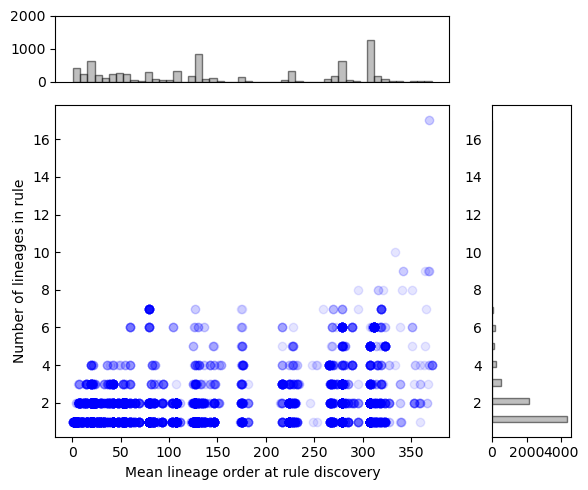

(0.12942262347551936, '1.35E-29')


In [35]:
def scatterHisto(dict1, dict2, x_axis='x-axis', y_axis='y-axis'):
    # Prepare data
    valid_keys, data1, data2 = todata(dict1, dict2)
    
    # Create a grid layout for scatter plot and histograms
    fig = plt.figure(figsize=(6, 5))
    gs = gridspec.GridSpec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5])  # Adjust ratios for proportions

    # X-axis histogram (top row, left column)
    ax_hist_x = fig.add_subplot(gs[0, 0])
    ax_hist_x.hist(data1, bins=50, color='gray', alpha=0.5, edgecolor='black', log=False)
    # ax_hist_x.set_xscale('log')  # Apply log scale to the x-axis histogram
    ax_hist_x.set_xticks([])  # Remove x-ticks for clarity
    # ax_hist_x.set_ylabel("Count")  # Label for the x-axis histogram
    ax_hist_x.set_yticks([0, 1000, 2000])

    # Scatter plot (bottom row, left column)
    ax_scatter = fig.add_subplot(gs[1, 0])
    ax_scatter.scatter(data1, data2, marker='o', color='b', alpha=0.1, label='Data Points', zorder=2)
    ax_scatter.set_xlabel(x_axis)
    ax_scatter.set_ylabel(y_axis)
    ax_scatter.yaxis.set_ticks_position('left')  # Force y-axis ticks on the scatter plot
    ax_scatter.tick_params(axis='y', which='both', direction='in')  # Ensure ticks are inward

    # # Y-axis histogram (bottom row, right column)
    ax_hist_y = fig.add_subplot(gs[1, 1], sharey=ax_scatter)
    ax_hist_y.hist(data2, bins=50, orientation='horizontal', color='gray', alpha=0.5, edgecolor='black')
    # ax_hist_y.set_yticks([])  # Hide y-ticks for the histogram
    ax_hist_y.tick_params(axis='y', left=False)  # Suppress y-ticks on the histogram
    ax_hist_y.set_ylabel("")  # No y-label for the histogram
    # # ax_hist_y.set_xscale('log')  # Apply log scale to the histogram x-axis
    # # ax_hist_y.set_xlabel("Count")  # Label for the histogram x-axis
    ax_hist_y.set_xticks([0, 2000, 4000])

    # plt.savefig('folditer2rulesFoldCount.svg', dpi=300, bbox_inches='tight')
    
    # Layout adjustment
    plt.tight_layout()
    plt.show()

scatterHisto(rule2fo_ave, rule2numFolds, 'Mean lineage order at rule discovery', 'Number of lineages in rule')
print(spearman(rule2fo_ave, rule2numFolds))

## 2. per reaction

In [36]:
# average of 1000 runs
rn2fo_ave = {index: np.mean(df_rns_folditer.loc[index]) for index in df_rns_folditer.index}

In [37]:
rn2numFoldsMax = {}
rn2numFoldsAll = {}

for rn, rules in rn2rules.items():
    lens = [len(rule) for rule in rules]
    rn2numFoldsMax[rn] = max(lens)
    
    foldset = set()
    for rule in rules:
        for fold in rule:
            foldset.add(fold)
    rn2numFoldsAll[rn] = len(foldset)

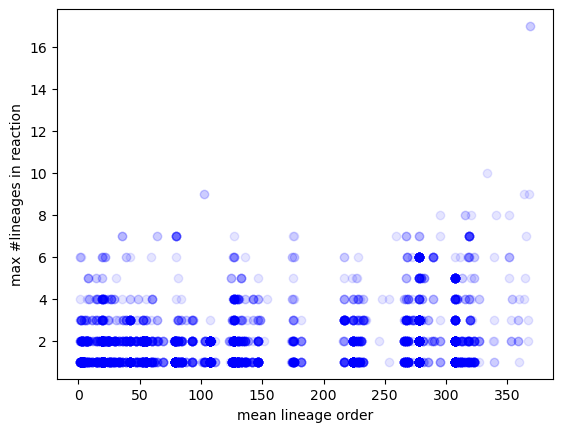

(0.02495068025761786, '5.89E-02')


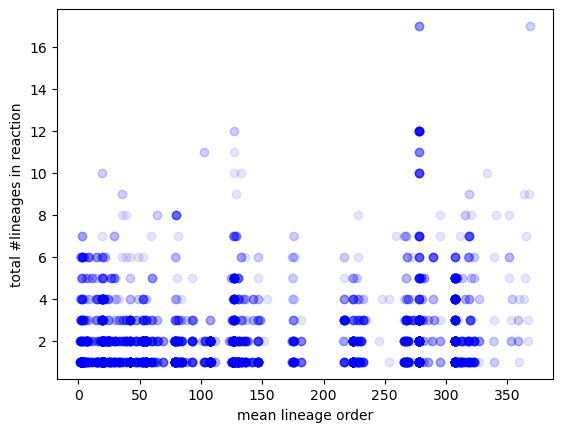

(-0.019302466822657235, '1.44E-01')


In [38]:
scatter(rn2fo_ave, rn2numFoldsMax, 'mean lineage order', 'max #lineages in reaction')
print(spearman(rn2fo_ave, rn2numFoldsMax))

scatter(rn2fo_ave, rn2numFoldsAll, 'mean lineage order', 'total #lineages in reaction')
print(spearman(rn2fo_ave, rn2numFoldsAll))

## shift in class composition

In [39]:
class2color = {'beta':'blue', 'alpha':'red', 'a+b':'green', 'a/b':'yellow', 'mixed':'purple', 'other':'grey'}

In [40]:
x2foMean = {}
x2foStd = {}
for x in df_folds_folditer.index:
    if x not in ['fold_independent', 'spontaneous']:
        x2foMean[x] = np.mean(df_folds_folditer.loc[x])
        x2foStd[x] = np.std(df_folds_folditer.loc[x])

print(len(x2foMean))
print(len(x2foStd))

396
396


In [41]:
# dict2csv(x2foMean, 'x2foMean_preATP.csv')

In [42]:
cl = 'beta'
# 371 iterations
ratios = []
for cutoff in np.arange(3.71, 375, 3.71):  # Start, stop, step
    before_cutoff = [k for k,v in x2foMean.items() if v < cutoff]
    print(len(before_cutoff), cutoff)
    ratios.append([x2class[x] for x in before_cutoff].count(cl)/cutoff)

2 3.71
6 7.42
10 11.129999999999999
13 14.84
17 18.55
21 22.26
24 25.97
28 29.68
33 33.39
36 37.1
39 40.81
43 44.52
48 48.23
50 51.94
55 55.65
57 59.36
61 63.07
65 66.78
70 70.49
70 74.19999999999999
70 77.91
79 81.61999999999999
90 85.33
92 89.03999999999999
93 92.74999999999999
94 96.46
94 100.16999999999999
108 103.88
109 107.58999999999999
111 111.3
113 115.00999999999999
113 118.72
113 122.42999999999999
119 126.13999999999999
124 129.85
128 133.56
143 137.27
143 140.98000000000002
147 144.69
152 148.4
155 152.11
156 155.82
156 159.53
156 163.24
156 166.95000000000002
156 170.66
158 174.37
191 178.08
191 181.79
191 185.5
191 189.21
191 192.92000000000002
191 196.63
191 200.34
191 204.05
191 207.76000000000002
191 211.47
192 215.18
197 218.89000000000001
198 222.6
205 226.31
255 230.02
257 233.73000000000002
257 237.44
257 241.15
257 244.86
259 248.57
261 252.28
262 255.99
263 259.7
263 263.40999999999997
267 267.12
274 270.83
279 274.53999999999996
281 278.25
284 281.96
290 285.66

In [43]:
len(ratios)

101

In [44]:
x2fo_ranked = {k: rank for rank, (k, v) in enumerate(sorted(x2foMean.items(), key=lambda item: item[1]), start=1)}

In [45]:
# 396 folds (1% = 4, 2% = 8...)

ratios = []
for cutoff in range(5, 400, 4):  # Start, stop, step
    before_cutoff = [k for k,v in x2fo_ranked.items() if v < cutoff]
    print(len(before_cutoff), cutoff)
    ratios.append([x2class[x] for x in before_cutoff].count(cl)/cutoff)

4 5
8 9
12 13
16 17
20 21
24 25
28 29
32 33
36 37
40 41
44 45
48 49
52 53
56 57
60 61
64 65
68 69
72 73
76 77
80 81
84 85
88 89
92 93
96 97
100 101
104 105
108 109
112 113
116 117
120 121
124 125
128 129
132 133
136 137
140 141
144 145
148 149
152 153
156 157
160 161
164 165
168 169
172 173
176 177
180 181
184 185
188 189
192 193
196 197
200 201
204 205
208 209
212 213
216 217
220 221
224 225
228 229
232 233
236 237
240 241
244 245
248 249
252 253
256 257
260 261
264 265
268 269
272 273
276 277
280 281
284 285
288 289
292 293
296 297
300 301
304 305
308 309
312 313
316 317
320 321
324 325
328 329
332 333
336 337
340 341
344 345
348 349
352 353
356 357
360 361
364 365
368 369
372 373
376 377
380 381
384 385
388 389
392 393
396 397


In [46]:
len(ratios)

99

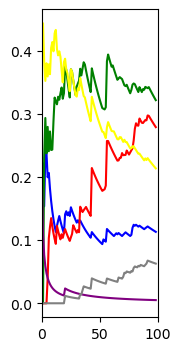

In [47]:
plt.figure(figsize=(1.5, 4))
for cl in class2color.keys():
    ratios = []
    for cutoff in range(5, 400, 4):
        before_cutoff = [k for k,v in x2foMean.items() if v < cutoff]
        ratios.append([x2class[x] for x in before_cutoff].count(cl)/cutoff)
    
    plt.plot(ratios, color=class2color[cl], label=cl)
plt.xlim([0, 100])
# plt.savefig('class_composition_change.svg', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
### percent stacked area

In [49]:
# class2color2 = {
#  'a/b': 'yellow',
#  'a+b': 'green',
#  'beta': 'blue',
#  'alpha': 'red',
#  'mixed': 'purple',
#  'other': 'grey'}

class2color2 = {
 'alpha': '#f03b37',
 'beta': '#163ee4',
 'a+b': '#fcdb24',
 'a/b': '#269d23',
 'mixed': '#a354f9',
 'other': 'grey'}

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_10968/2053139968.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


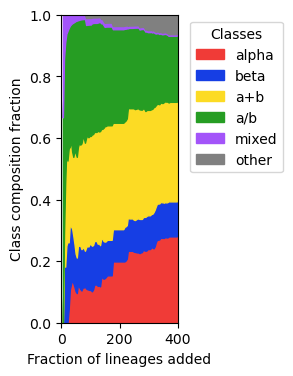

In [50]:
cutoffs = range(5, 400, 4)

# Compute the percentages for each class at each cutoff
class_ratios = {}
for cl in class2color2.keys():
    ratios = []
    for cutoff in cutoffs:
        before_cutoff = [k for k, v in x2foMean.items() if v < cutoff]
        ratios.append([x2class[x] for x in before_cutoff].count(cl) / len(before_cutoff) if before_cutoff else 0)
    class_ratios[cl] = ratios

# Convert to a stacked area data format
stacked_data = np.array([class_ratios[cl] for cl in class2color2.keys()])
stacked_data = np.nan_to_num(stacked_data)  # Handle any NaN values
stacked_data = stacked_data / stacked_data.sum(axis=0)  # Normalize to percentages

# Create the percent stacked area plot
plt.figure(figsize=(1.5, 4))
cumulative_data = np.cumsum(stacked_data, axis=0)
cutoff_range = np.array(list(cutoffs))

for i, cl in enumerate(class2color2.keys()):
    plt.fill_between(
        cutoff_range, 
        cumulative_data[i - 1] if i > 0 else 0, 
        cumulative_data[i], 
        color=class2color2[cl], 
        label=cl
    )

plt.xlim([cutoffs.start, 396])  # wide
plt.xticks([0, 200, 400])  # slim
plt.ylim([0, 1])
plt.xlabel("Fraction of lineages added")
plt.ylabel("Class composition fraction")
plt.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# plt.savefig('class_composition_cumulative_slim.svg', dpi=300, bbox_inches='tight')
plt.show()


# class compositions for all ECOD vs. metabolic lineages

In [51]:
x2class_hit = {k:v for k,v in x2class.items() if k in x2ds}
x2class_scope = {k:v for k,v in x2class.items() if k in x2ns}
len(x2class_hit), len(x2class_scope)

(2230, 396)

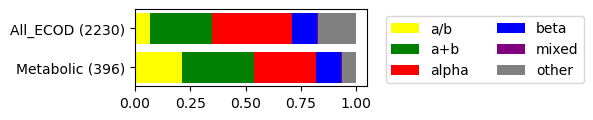

In [52]:
dict2 = Counter(x2class_hit.values())
dict1 = Counter(x2class_scope.values())

# Combine dictionaries into a list
dicts = [dict1, dict2]

# Keys for the bar chart
keys = ['a/b', 'a+b', 'alpha', 'beta', 'mixed', 'other']
# keys = list(dict1.keys())

# Normalize each dictionary
fractions = [{key: value / np.sum(list(d.values())) for key, value in d.items()} for d in dicts]

# Data for stacked bar chart
data = {key: [fractions[i].get(key, 0) for i in range(len(dicts))] for key in keys}

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(3, 1))

# Positions for each bar group
y = np.arange(len(dicts))

# Plot each category as a stack with custom colors
left = np.zeros(len(dicts))
for key in keys:
    values = data[key]
    ax.barh(y, values, left=left, label=key, color=class2color[key])
    left += values  # Update left for stacking

# Add labels and legend
ax.set_yticks(y)
ax.set_yticklabels(['Metabolic (396)', 'All_ECOD (2230)'])
ax.legend(bbox_to_anchor=(1.05, 1), ncol=2)


# plt.savefig('folds_class_composition_evo.svg', dpi=300, bbox_inches='tight')
plt.show()

In [53]:
data

{'a/b': [0.21464646464646464, 0.06816143497757847],
 'a+b': [0.32323232323232326, 0.2789237668161435],
 'alpha': [0.2803030303030303, 0.36278026905829597],
 'beta': [0.11363636363636363, 0.11300448430493273],
 'mixed': [0.005050505050505051, 0.004932735426008968],
 'other': [0.06313131313131314, 0.17219730941704037]}

In [54]:
0.21464646464646464/0.06816143497757847  # enrichment

3.149089580010633

# class compositions for rules of length 1~3

In [55]:
# remove reactions that do not appear in our runs from rn2rules
rn2rules_scope = {rn:rules for rn, rules in rn2rules.items() if rn in df_rns_folditer.index}
len(rn2rules_scope)

5730

In [56]:
all_rules = []
for rn, rules in rn2rules_scope.items():
    for rule in rules:
        all_rules.append(rule)
len(all_rules), len(set(all_rules))

(7558, 763)

In [57]:
# take the set
# rule1 = [rule for rule in set(all_rules) if len(rule) == 1]
# rule1.remove(frozenset({'spontaneous'}))
# rule2 = [rule for rule in set(all_rules) if len(rule) == 2]
# rule3 = [rule for rule in set(all_rules) if len(rule) == 3]
# len(rule1), len(rule2), len(rule3)

# do not take the set
rule1 = [rule for rule in all_rules if len(rule) == 1]
rule1 = [v for v in rule1 if v != frozenset({'spontaneous'})]
rule2 = [rule for rule in all_rules if len(rule) == 2]
rule3 = [rule for rule in all_rules if len(rule) == 3]
rule4plus = [rule for rule in all_rules if len(rule) > 3]
len(rule1), len(rule2), len(rule3), len(rule4plus), len(rule1 + rule2 + rule3 + rule4plus)  # < 7558 since 'spontaneous' were removed

(4222, 2127, 501, 595, 7445)

In [58]:
# detail look at 4plus rules

rule4plusLen = [len(v) for v in rule4plus]
Counter(rule4plusLen)

Counter({4: 235, 6: 177, 5: 119, 7: 49, 8: 6, 9: 6, 17: 2, 10: 1})

In [59]:
class2rulesNum1 = {'a/b': 0, 'a+b': 0, 'alpha': 0, 'beta': 0, 'mixed': 0, 'other': 0}
class2rulesNum2 = {'a/b': 0, 'a+b': 0, 'alpha': 0, 'beta': 0, 'mixed': 0, 'other': 0}
class2rulesNum3 = {'a/b': 0, 'a+b': 0, 'alpha': 0, 'beta': 0, 'mixed': 0, 'other': 0}
class2rulesNum4plus = {'a/b': 0, 'a+b': 0, 'alpha': 0, 'beta': 0, 'mixed': 0, 'other': 0}

for rule in rule1:
    for fold in rule:
        class2rulesNum1[x2class[fold]] += 1
for rule in rule2:
    for fold in rule:
        class2rulesNum2[x2class[fold]] += 1/2
for rule in rule3:
    for fold in rule:
        class2rulesNum3[x2class[fold]] += 1/3
for rule in rule4plus:
    for fold in rule:
        class2rulesNum4plus[x2class[fold]] += 1/len(rule)

In [60]:
print(np.sum(list(class2rulesNum1.values())))
print(np.sum(list(class2rulesNum2.values())))
print(np.sum(list(class2rulesNum3.values())))
print(np.sum(list(class2rulesNum4plus.values())))

4222
2127.0
501.0000000000001
594.9999999999972


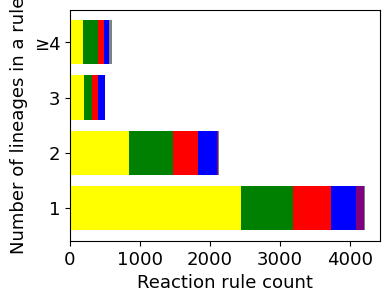

In [61]:
dict1 = class2rulesNum1
dict2 = class2rulesNum2
dict3 = class2rulesNum3
dict4 = class2rulesNum4plus

dicts = [dict1, dict2, dict3, dict4]

# Keys for the bar chart
keys = list(dict1.keys())

# Normalize each dictionary
fractions = [{key: value for key, value in d.items()} for d in dicts]

# Data for stacked bar chart
data = {key: [fractions[i][key] for i in range(len(dicts))] for key in keys}

# Plot horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(4, 3))

# Positions for each bar group
y = np.arange(len(dicts))

# Plot each category as a stack with custom colors
left = np.zeros(len(dicts))
for key in keys:
    values = data[key]
    ax.barh(y, values, left=left, label=key, color=class2color[key])
    left += values  # Update left for stacking

# Add labels and legend
ax.set_yticks(y)
ax.set_yticklabels(['1', '2', '3', '≥4'], fontsize=13)
ax.set_xticks([0, 1000, 2000, 3000, 4000])  # Set tick positions
ax.set_xticklabels(['0', '1000', '2000', '3000', '4000'], fontsize=13)

# ax.legend(bbox_to_anchor=(1.05, 1))
plt.ylabel('Number of lineages in a rule', fontsize=13)
plt.xlabel('Reaction rule count', fontsize=13)

# plt.savefig('rules_class_fractions.svg', dpi=300, bbox_inches='tight')
plt.show()

In [62]:
data

{'a/b': [2441, 838.0, 196.33333333333454, 183.58984593837437],
 'a+b': [747, 632.0, 113.99999999999946, 214.5570728291293],
 'alpha': [544, 361.5, 93.33333333333309, 93.93506069094342],
 'beta': [365, 269.5, 95.66666666666639, 70.85952380952388],
 'mixed': [104, 13.5, 0.3333333333333333, 2.892857142857143],
 'other': [21, 12.5, 1.3333333333333333, 29.165639589168986]}

In [63]:
2441/(2441+747+544+365+104+21) / 0.21464646464646464

2.693554769136456

In [64]:
2441/(2441+747+544+365+104+21) / 0.06816143497757847

8.48224525667556

### useful numbers

In [65]:
cpds_scope = list(df_cpds_folditer[df_cpds_folditer.columns[0]].keys())
print(len(cpds_scope))
rns_scope = list(df_rns_folditer[df_rns_folditer.columns[0]].keys())
print(len(rns_scope))

4294
7678


In [66]:
x2ns['2003']/len(cpds_scope)

0.23614345598509548

In [67]:
x2ns['3997']/len(cpds_scope)

0.7696786213320913

In [68]:
print(x2class['206'], x2name.get('206', 'none'))  # ATP-grasp
print(x2class['325'], x2name.get('325', 'none'))  # hammerhead

a+b none
a+b alpha/beta-Hammerhead/Barrel-sandwich hybrid


In [69]:
class2rulesNum1

{'a/b': 2441, 'a+b': 747, 'alpha': 544, 'beta': 365, 'mixed': 104, 'other': 21}

In [70]:
2441/(747 + 544 + 365 + 104 + 21)

1.3705783267827063

In [71]:
2441/(2441 + 747 + 544 + 365 + 104 + 21)

0.5781620085267646

In [72]:
len(set(list(df_rns_folditer.index)))  # rns_scope

7678

In [73]:
len(set([eval(v)[0] for v in list(df_rules_folditer.index)]))  # rns_scope_fold-gated

5730

In [74]:
len(set([eval(v)[1] for v in list(df_rules_folditer.index)]))  # rules_scope

763

In [75]:
len([eval(v)[1] for v in list(df_rules_folditer.index)])  # rules_scope with redundancy

7558

# carbon fixation timing

In [76]:
df_rns_cumiter_NONE = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rns_cumiter_NONE.csv', index_col=0)
df_rns_cumiter_C00002 = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_cumiter_preATP.csv', index_col=0)
# df_rns_cumiter_ALL = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_ALL/rns_cumiter_ALL.csv', index_col=0)

In [77]:
df_rns_cumiter_NONE['26262']

RZ_492         1
R00363         1
RZ_510         1
RZ_511         1
R00347_v4      1
            ... 
R00019_v1    865
R10572_v1    866
R11874       867
R11945_v1    868
R11945_v2    868
Name: 26262, Length: 7678, dtype: int64

In [78]:
run2iter2rns_NONE = {}
for run in df_rns_cumiter_NONE.columns:
    iter2rns = {}
    for rn, i in df_rns_cumiter_NONE[run].items():
        if i not in iter2rns.keys():
            iter2rns[i] = [rn]
        else:
            iter2rns[i].append(rn)
    run2iter2rns_NONE[run] = iter2rns

lens = []
for run in df_rns_cumiter_NONE.columns:
    lens.append(max(df_rns_cumiter_NONE[run]))
print(max(lens))

# run2iter2rns_C00002 = {}
# for run in df_rns_cumiter_C00002.columns:
#     iter2rns = {}
#     for rn, i in df_rns_cumiter_C00002[run].items():
#         if i not in iter2rns.keys():
#             iter2rns[i] = [rn]
#         else:
#             iter2rns[i].append(rn)
#     run2iter2rns_C00002[run] = iter2rns

# run2iter2rns_ALL = {}
# for run in df_rns_cumiter_ALL.columns:
#     iter2rns = {}
#     for rn, i in df_rns_cumiter_ALL[run].items():
#         if i not in iter2rns.keys():
#             iter2rns[i] = [rn]
#         else:
#             iter2rns[i].append(rn)
#     run2iter2rns_ALL[run] = iter2rns

886


In [79]:
def get_versionless_reactions(reactions):
    versionless_reactions = list()
    for i in reactions:
        versionless_reactions.append(get_versionless_reaction(i))
    return set(versionless_reactions)

def get_versionless_reaction(reaction):
    match = re.match(r'(.+)_v\d', reaction)
    if match!=None:
        return match[1]
    else:
        return reaction

In [80]:
len(rns_scope), len(get_versionless_reactions(rns_scope))

(7678, 6677)

In [81]:
# exclude new reactions added after release of vanilla (standard network expansion) paper
vanilla_rns = set(get_versionless_reactions(rn2direction.keys()))

for c in ['R00331', 'R00333', 'R01940', 'R02571', 'R04405']:
    vanilla_rns.remove(c)  # required cpd not available, but considered 'complete' in vanilla
module2rns_set = {k: set(v) & vanilla_rns for k, v in module2rns.items()}
len(module2rns_set)

479

In [82]:
def getModComp(run2iter2rns):
    run2module_completion = {}

    for run, iter2rns in run2iter2rns.items():
        cm = {'M00165', 'M00173', 'M00374', 'M00375', 'M00376', 'M00377'}  # Use a set for faster removal
        module2completion = {}
        rn_set = set()  # Use a set for O(1) lookup
        
        for i, rns in iter2rns.items():
            rn_set.update(r[:6] for r in rns)  # Extract first 6 chars and update set
            
            # Check for module completion
            completed_modules = {m for m in cm if module2rns_set[m].issubset(rn_set)}
            
            # Update completions and remove completed modules from tracking
            for m in completed_modules:
                module2completion[m] = i
                cm.remove(m)  # Remove from tracking set
            
            if not cm:  # Stop early if all modules are completed
                break
        
        run2module_completion[run] = module2completion
    
    return run2module_completion

In [83]:
run2module_completion_NONE = getModComp(run2iter2rns_NONE)
# run2module_completion_C00002 = getModComp(run2iter2rns_C00002)
# run2module_completion_ALL = getModComp(run2iter2rns_ALL)

In [84]:
run2module_completion_NONE

{'26262': {'M00165': 339,
  'M00375': 692,
  'M00173': 734,
  'M00376': 734,
  'M00374': 734,
  'M00377': 843},
 '47851': {'M00165': 330,
  'M00375': 687,
  'M00173': 738,
  'M00376': 738,
  'M00374': 738,
  'M00377': 840},
 '88490': {'M00165': 325,
  'M00376': 666,
  'M00375': 661,
  'M00374': 661,
  'M00173': 673,
  'M00377': 838},
 '92249': {'M00165': 334,
  'M00376': 687,
  'M00375': 682,
  'M00374': 682,
  'M00173': 694,
  'M00377': 841},
 '20023': {'M00165': 329,
  'M00376': 691,
  'M00375': 686,
  'M00374': 686,
  'M00173': 698,
  'M00377': 844},
 '85514': {'M00165': 347,
  'M00376': 680,
  'M00375': 675,
  'M00374': 675,
  'M00173': 687,
  'M00377': 848},
 '83998': {'M00165': 327,
  'M00376': 687,
  'M00375': 682,
  'M00374': 682,
  'M00173': 696,
  'M00377': 843},
 '21172': {'M00165': 332,
  'M00375': 667,
  'M00173': 731,
  'M00376': 731,
  'M00374': 731,
  'M00377': 836},
 '45686': {'M00165': 323,
  'M00376': 666,
  'M00375': 661,
  'M00374': 661,
  'M00173': 673,
  'M00377'

In [85]:
modules = ['M00165', 'M00173', 'M00374', 'M00375', 'M00376', 'M00377']
for m in modules:
    print(m, module2name[m])

M00165 Reductive pentose phosphate cycle (Calvin cycle)
M00173 Reductive citrate cycle (Arnon-Buchanan cycle)
M00374 Dicarboxylate-hydroxybutyrate cycle
M00375 Hydroxypropionate-hydroxybutylate cycle
M00376 3-Hydroxypropionate bi-cycle
M00377 Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway)


In [86]:
mod2name_short = {'M00165': 'Calvin cycle', 'M00173': 'rTCA cycle', 'M00374': 'DC-4HB', 'M00375': '3HP-4HB', 'M00376': r'$\text{(3HP)}_{2}$', 'M00377': 'Wood-Ljungdahl'}

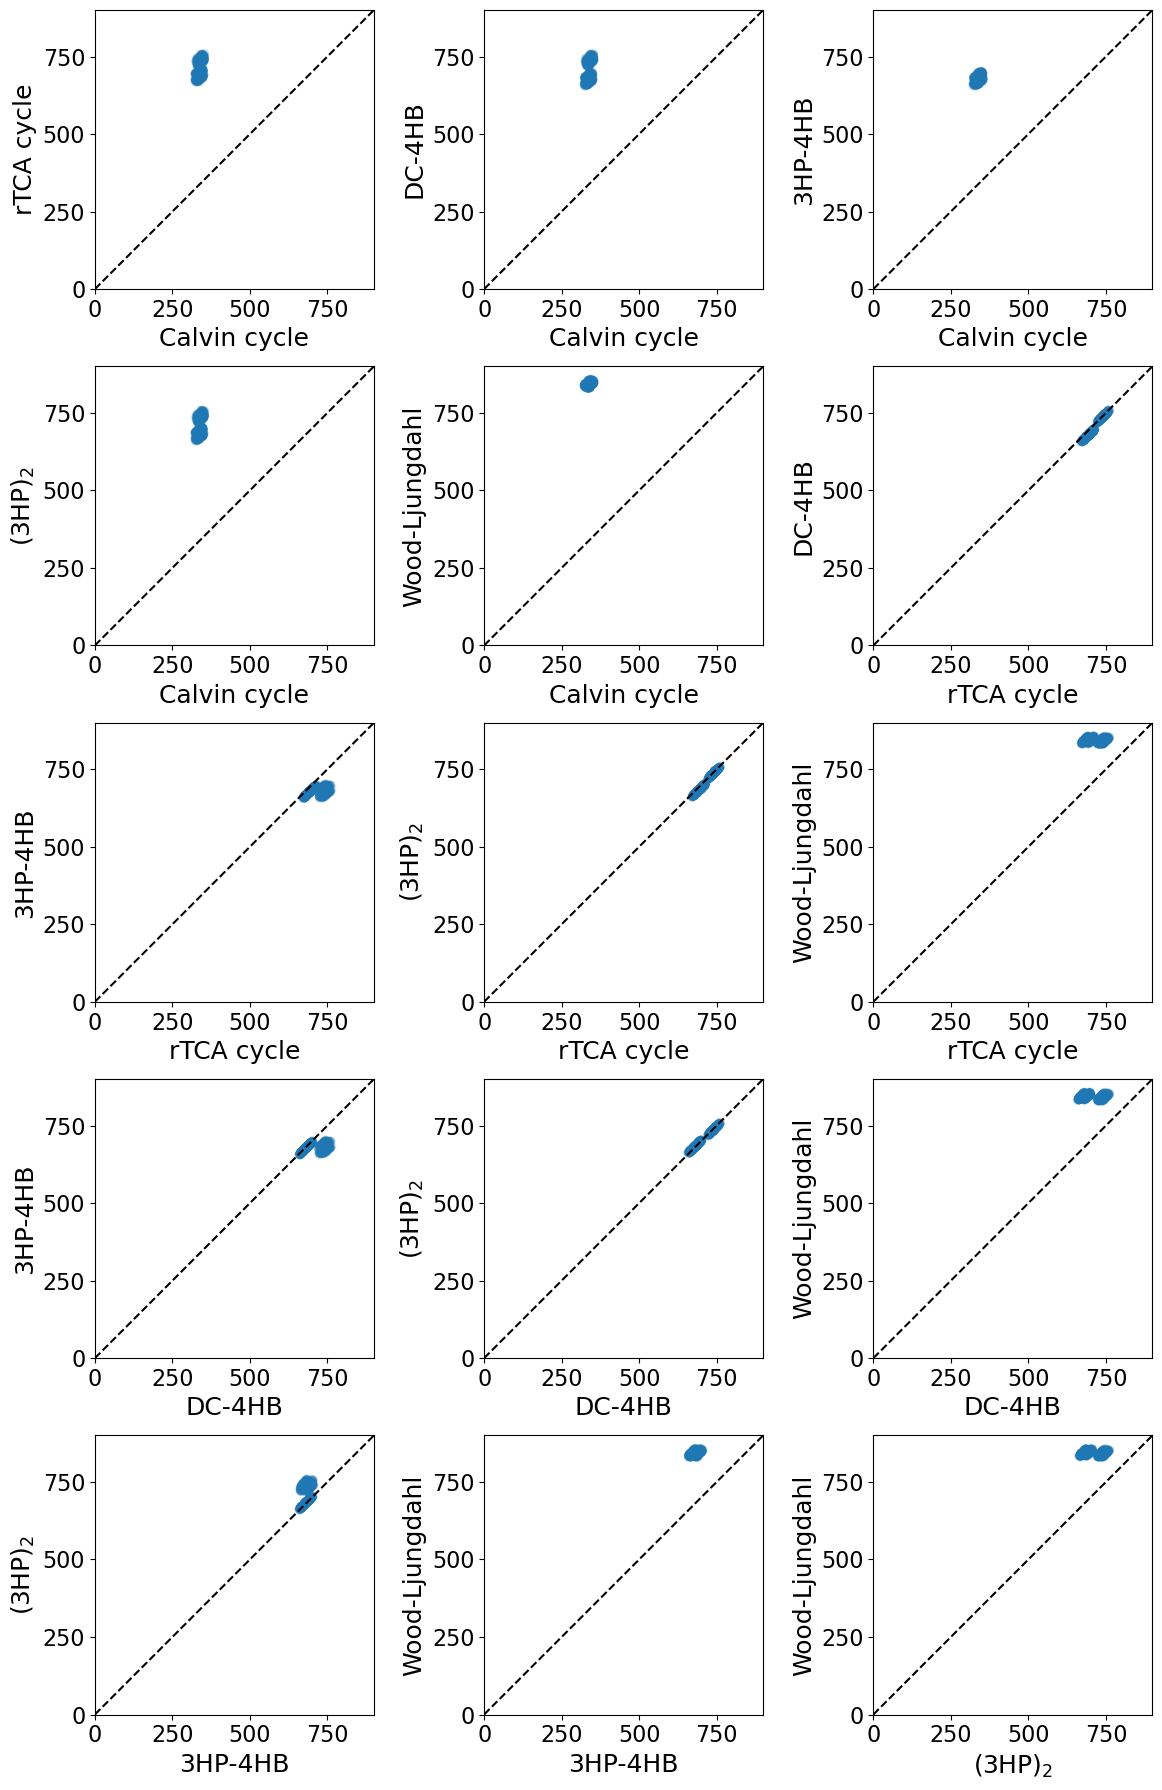

In [87]:
# Extract module completion times for each run
modules = ['M00165', 'M00173', 'M00374', 'M00375', 'M00376', 'M00377']
run2module_times = {m: {run: mod2iter[m] for run, mod2iter in run2module_completion_NONE.items()} for m in modules}

# Define axis limits and tick marks
axis_ticks = [0, 250, 500, 750]
axis_limits = [0, 900]

# Font sizes
label_fontsize = 18
tick_fontsize = 16

# Generate scatter plots for all module pairs
fig, axes = plt.subplots(5, 3, figsize=(12, 18))  # 5 rows, 3 columns
axes = axes.flatten()  # Flatten for easy indexing

for idx, (mod1, mod2) in enumerate(combinations(modules, 2)):
    ax = axes[idx]
    x_vals = list(run2module_times[mod1].values())
    y_vals = list(run2module_times[mod2].values())

    ax.scatter(x_vals, y_vals, alpha=0.1)
    ax.plot(axis_limits, axis_limits, color='black', linestyle='--')  # Identity line
    ax.set_xlabel(mod2name_short[mod1], fontsize=label_fontsize)
    ax.set_ylabel(mod2name_short[mod2], fontsize=label_fontsize)
    ax.set_xlim(axis_limits)
    ax.set_ylim(axis_limits)
    ax.set_xticks(axis_ticks)
    ax.set_yticks(axis_ticks)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    # ax.set_title(f'{mod2name_short[mod1]} vs. {mod2name_short[mod2]}', fontsize=18)
    ax.set_aspect("equal")  # Ensure square plots

plt.tight_layout()
# plt.savefig(f'carbon_fix_comparison.svg', dpi=300, bbox_inches='tight')
plt.show()

In [88]:
for m in ['M00165', 'M00173', 'M00377', 'M00374', 'M00375', 'M00376']:
    print(m, np.mean(list(run2module_times[m].values())), round(np.std(list(run2module_times[m].values())), 3), mod2name_short[m], module2name[m])

M00165 337.603 6.658 Calvin cycle Reductive pentose phosphate cycle (Calvin cycle)
M00173 714.992 25.664 rTCA cycle Reductive citrate cycle (Arnon-Buchanan cycle)
M00377 845.176 6.183 Wood-Ljungdahl Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway)
M00374 708.718 31.39 DC-4HB Dicarboxylate-hydroxybutyrate cycle
M00375 680.765 10.759 3HP-4HB Hydroxypropionate-hydroxybutylate cycle
M00376 711.273 29.021 $\text{(3HP)}_{2}$ 3-Hydroxypropionate bi-cycle


# All module completion

In [89]:
run2iter2rns_NONE = {}
for run in df_rns_cumiter_NONE.columns:
    iter2rns = {}
    for rn, i in df_rns_cumiter_NONE[run].items():
        if i not in iter2rns.keys():
            iter2rns[i] = [rn]
        else:
            iter2rns[i].append(rn)
    run2iter2rns_NONE[run] = iter2rns

lens = []
for run in df_rns_cumiter_NONE.columns:
    lens.append(max(df_rns_cumiter_NONE[run]))
print(max(lens))

run2iter2rns_C00002 = {}
for run in df_rns_cumiter_C00002.columns:
    iter2rns = {}
    for rn, i in df_rns_cumiter_C00002[run].items():
        if i not in iter2rns.keys():
            iter2rns[i] = [rn]
        else:
            iter2rns[i].append(rn)
    run2iter2rns_C00002[run] = iter2rns

886


In [90]:
# from vanilla Table S11
all_mods = set(['M00580', 'M00916', 'M00338', 'M00118', 'M00005', 'M00345', 'M00170', 'M00308', 'M00115', 'M00919', 'M00020', 'M00027', 'M00168', 'M00003', 'M00171', 'M00169', 'M00166', 'M00008', 'M00006', 'M00064', 'M00877', 'M00050', 'M00015', 'M00172', 'M00018', 'M00061', 'M00875', 'M00527', 'M00131', 'M00049', 'M00876', 'M00552', 'M00630', 'M00631', 'M00633', 'M00844', 'M00132', 'M00309', 'M00029', 'M00134', 'M00843', 'M00842', 'M00609', 'M00133', 'M00175', 'M00125', 'M00555', 'M00047', 'M00022', 'M00896', 'M00004', 'M00007', 'M00358', 'M00165', 'M00167', 'M00344', 'M00051', 'M00899', 'M00024', 'M00040', 'M00910', 'M00025', 'M00840', 'M00841', 'M00549', 'M00091', 'M00554', 'M00931', 'M00930', 'M00126', 'M00632', 'M00023', 'M00019', 'M00570', 'M00935', 'M00052', 'M00119', 'M00141', 'M00048', 'M00092', 'M00090', 'M00140', 'M00787', 'M00891', 'M00923', 'M00046', 'M00120', 'M00914', 'M00794', 'M00422', 'M00793', 'M00021', 'M00433', 'M00525', 'M00579', 'M00796', 'M00795', 'M00535', 'M00785', 'M00010', 'M00346', 'M00012', 'M00016', 'M00017', 'M00028', 'M00033', 'M00173', 'M00845', 'M00879', 'M00801', 'M00797', 'M00798', 'M00432', 'M00088', 'M00802', 'M00904', 'M00608', 'M00032', 'M00095', 'M00013', 'M00849', 'M00053', 'M00577', 'M00176', 'M00596', 'M00082', 'M00418', 'M00595', 'M00829', 'M00836', 'M00847', 'M00001', 'M00365', 'M00366', 'M00367', 'M00364', 'M00114', 'M00116', 'M00002', 'M00377', 'M00356', 'M00530', 'M00620', 'M00563', 'M00529', 'M00531', 'M00884', 'M00881', 'M00882', 'M00932', 'M00883', 'M00034', 'M00124', 'M00135', 'M00913', 'M00915', 'M00174', 'M00136', 'M00868', 'M00675', 'M00637', 'M00736', 'M00638', 'M00368', 'M00776', 'M00533', 'M00568', 'M00538', 'M00624', 'M00622', 'M00921', 'M00569', 'M00894', 'M00042', 'M00150', 'M00545', 'M00374', 'M00830', 'M00138', 'M00149', 'M00933', 'M00661', 'M00901', 'M00912', 'M00038', 'M00674', 'M00044', 'M00918', 'M00890', 'M00775', 'M00037', 'M00774', 'M00848', 'M00112', 'M00122', 'M00934', 'M00773', 'M00117', 'M00372', 'M00128', 'M00740', 'M00567', 'M00741', 'M00528', 'M00375', 'M00376', 'M00357', 'M00804', 'M00900', 'M00373', 'M00142', 'M00144', 'M00145', 'M00903', 'M00087', 'M00086', 'M00100', 'M00066', 'M00113'])
for m in all_mods - set(module2rns_set.keys()):
    all_mods.remove(m)  # M00166 and M00167 no longer exist on KEGG
len(all_mods)

217

In [91]:
def getModComp_all(run2iter2rns, all_mods):
    run2module_completion = {}

    for run, iter2rns in run2iter2rns.items():
        all_mods_copy = all_mods.copy()
        module2completion = {}
        rn_set = set()  # Use a set for O(1) lookup
        
        for i, rns in iter2rns.items():
            rn_set.update(r[:6] for r in rns)  # Extract first 6 chars and update set
            
            # Check for module completion
            completed_modules = {m for m in all_mods_copy if module2rns_set[m].issubset(rn_set)}
            
            # Update completions and remove completed modules from tracking
            for m in completed_modules:
                module2completion[m] = i
                all_mods_copy.remove(m)  # Remove from tracking set
            
            if not all_mods_copy:  # Stop early if all modules are completed
                break
        
        run2module_completion[run] = module2completion
    
    return run2module_completion

In [92]:
run2module_completion_NONE = getModComp_all(run2iter2rns_NONE, all_mods)
run2module_completion_C00002 = getModComp_all(run2iter2rns_C00002, all_mods)

In [93]:
module_completionNONE_all_runs = {}
for run, module_completion in run2module_completion_NONE.items():
    for mod, i in module_completion.items():
        if mod not in module_completionNONE_all_runs:
            module_completionNONE_all_runs[mod] = [i]
        else:
            module_completionNONE_all_runs[mod].append(i)
mean_module_completionNONE = {k:np.mean(v) for k,v in module_completionNONE_all_runs.items()}
std_module_completionNONE = {k:np.std(v) for k,v in module_completionNONE_all_runs.items()}

In [94]:
module_completionC00002_all_runs = {}
for run, module_completion in run2module_completion_C00002.items():
    for mod, i in module_completion.items():
        if mod not in module_completionC00002_all_runs:
            module_completionC00002_all_runs[mod] = [i]
        else:
            module_completionC00002_all_runs[mod].append(i)
mean_module_completionC00002 = {k:np.mean(v) for k,v in module_completionC00002_all_runs.items()}
std_module_completionC00002 = {k:np.std(v) for k,v in module_completionC00002_all_runs.items()}

## compare with vanilla (= standard network expansion; Goldford et al. 2024)

In [95]:
vanilla_mod2completion_SI = csv2dict('../data/assets/vanilla_SI_mod2completion.csv')
vanilla_mod2completion_SI.pop('\ufeffM00580')
vanilla_mod2completion_SI['M00580'] = 8

# vanilla with H2O2 fix!
vanilla = pd.read_pickle('../data/assets/vanilla_result_object.pkl')
vanilla_10AA = pd.read_pickle('../data/assets/vanilla_10AA_result_object.pkl')

In [96]:
iter2rns = {}
for rn, i in vanilla.scope.rn_iteration_dict.items():
    if i not in iter2rns.keys():
        iter2rns[i] = [rn]
    else:
        iter2rns[i].append(rn)

all_mods_copy = all_mods.copy()
vanilla_mod2completion_70seed = {}
rn_set = set()
for i, rns in iter2rns.items():
    rn_set.update(r[:6] for r in rns)  # Extract first 6 chars and update set
    
    # Check for module completion
    completed_modules = {m for m in all_mods_copy if module2rns_set[m].issubset(rn_set)}
    
    # Update completions and remove completed modules from tracking
    for m in completed_modules:
        vanilla_mod2completion_70seed[m] = i
        all_mods_copy.remove(m)  # Remove from tracking set
    
    if not all_mods_copy:  # Stop early if all modules are completed
        break

In [97]:
iter2rns = {}
for rn, i in vanilla_10AA.scope.rn_iteration_dict.items():
    if i not in iter2rns.keys():
        iter2rns[i] = [rn]
    else:
        iter2rns[i].append(rn)

all_mods_copy = all_mods.copy()
vanilla_mod2completion_80seed = {}
rn_set = set()
for i, rns in iter2rns.items():
    rn_set.update(r[:6] for r in rns)  # Extract first 6 chars and update set
    
    # Check for module completion
    completed_modules = {m for m in all_mods_copy if module2rns_set[m].issubset(rn_set)}
    
    # Update completions and remove completed modules from tracking
    for m in completed_modules:
        vanilla_mod2completion_80seed[m] = i
        all_mods_copy.remove(m)  # Remove from tracking set
    
    if not all_mods_copy:  # Stop early if all modules are completed
        break

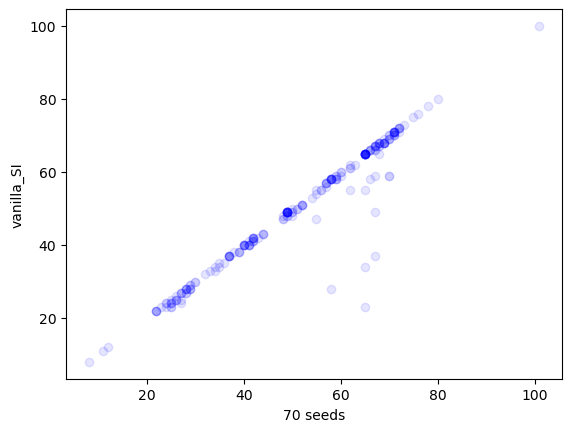

In [98]:
scatter(vanilla_mod2completion_70seed, vanilla_mod2completion_SI, x_axis='70 seeds', y_axis='vanilla_SI')
# most likely due to H2O2 fix

## TableS_module_completion_comparison

In [99]:
# with ties
# x2rulesNum_rank = {key: rank for key, rank in zip(x2rulesNum_scope.keys(), rankdata(list(x2rulesNum_scope.values()), method='min'))}
# x2foMean_NONE_rank = {key: rank for key, rank in zip(pre2x2foMean['NONE'].keys(), rankdata(list(pre2x2foMean['NONE'].values()), method='min'))}
# x2foMean_ALL_rank = {key: rank for key, rank in zip(pre2x2foMean['ALL'].keys(), rankdata(list(pre2x2foMean['ALL'].values()), method='min'))}

In [100]:
vanilla_mod2completion_SI_od = dict(sorted(vanilla_mod2completion_SI.items(), key=lambda item: int(item[1])))
vanilla_mod2completion_SI_od.pop('M00166')
vanilla_mod2completion_SI_od.pop('M00167')
vanilla_mod2completion_SI_od.pop('Anammox')
vanilla_mod2completion_SI_od.pop('ReductiveGlycineModule')

dict1 = {key: rank for key, rank in zip(vanilla_mod2completion_SI_od.keys(), rankdata(list(vanilla_mod2completion_SI_od.values()), method='min'))}
dict2 = {key: rank for key, rank in zip(vanilla_mod2completion_80seed.keys(), rankdata(list(vanilla_mod2completion_80seed.values()), method='min'))}
dict3 = {key: rank for key, rank in zip(mean_module_completionNONE.keys(), rankdata(list(mean_module_completionNONE.values()), method='min'))}
dict4 = {key: rank for key, rank in zip(mean_module_completionC00002.keys(), rankdata(list(mean_module_completionC00002.values()), method='min'))}

In [101]:
len(dict1), len(dict2), len(dict3), len(dict4)

(217, 217, 217, 217)

In [102]:
data = []
for m in vanilla_mod2completion_SI_od.keys():
    data.append({
        'KEGG Module ID': m,
        'Description': module2name[m],
        'Completion order (vanilla_SI)': dict1[m],
        'Completion order (vanilla+10AA)': dict2[m],
        'Completion order (NONE)': dict3[m],
        'Completion order (C00002)': dict4[m]
    })

df = pd.DataFrame(data)  # Convert list of dicts to DataFrame
df.head()

,KEGG Module ID,Description,Completion order (vanilla_SI),Completion order (vanilla+10AA),Completion order (NONE),Completion order (C00002)
0,M00580,"Pentose phosphate pathway, archaea, fructose 6...",1,1,1,2
1,M00916,"Pyridoxal-P biosynthesis, R5P + glyceraldehyde...",2,1,2,1
2,M00338,"Cysteine biosynthesis, homocysteine + serine =...",3,3,3,21
3,M00118,"Glutathione biosynthesis, glutamate => glutath...",4,4,49,41
4,M00005,"PRPP biosynthesis, ribose 5P => PRPP",4,4,5,35


In [103]:
# df.to_csv('TableS_module_completion_comparison.csv', index=False)

In [104]:
d = {}
for rn, i in vanilla_10AA.scope.rn_iteration_dict.items():
    d[rn[:6]] = i

In [105]:
for r in module2rns_set['M00115']:
    print(r, d[r])

R00257 22
R04292 6
R00481 50
R07407 24
R03348 8
R03005 21
R00189 22
R07410 23


In [106]:
vanilla_10AA.scope.cpd_iteration_dict['C00027']

50

In [107]:
dict2['M00115']

137

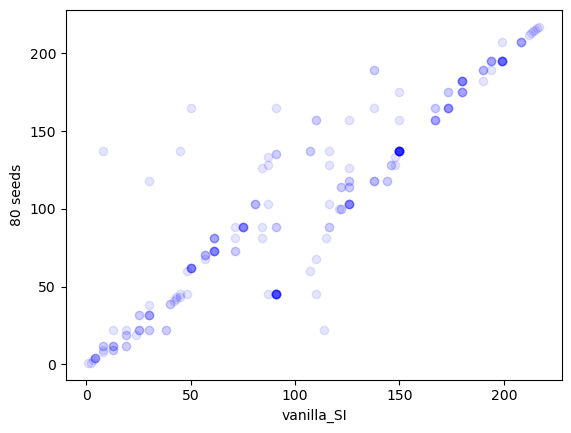

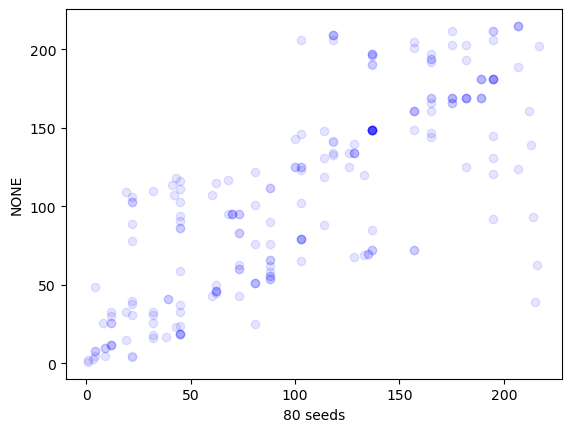

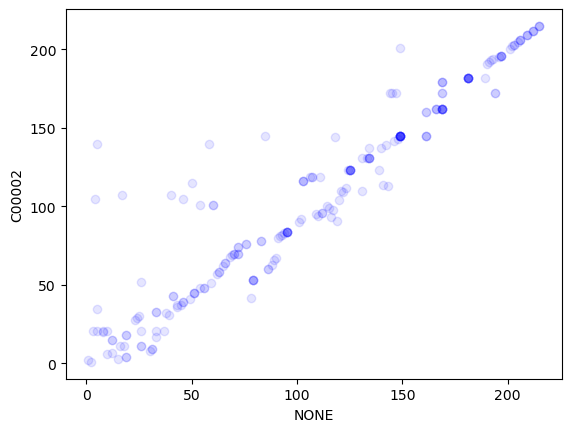

In [108]:
scatter(dict1, dict2, x_axis='vanilla_SI', y_axis='80 seeds')
scatter(dict2, dict3, x_axis='80 seeds', y_axis='NONE')
scatter(dict3, dict4, x_axis='NONE', y_axis='C00002')

In [109]:
def bokeh_scatter(d1, d2, x_label, y_label):
    p = figure(width=400, height=300)
    
    valid_keys, data1, data2 = todata(d1, d2)
    # data2 = np.log10(data2)
    labels = [x2name.get(key, key) for key in valid_keys]
    # colors = ['red' if k in evo else 'blue' for k in valid_keys]
    
    # source
    source = ColumnDataSource(data={
        'x': data1,
        'y': data2,
        'label': labels
    })
    
    p.scatter('x', 'y', source=source, size=10, alpha=0.5, line_color=None)
    
    # Add hover tool
    hover = HoverTool()
    hover.tooltips = [("X", "@label")]
    p.add_tools(hover)
    
    # Customize plot
    p.xaxis.axis_label = x_label
    p.yaxis.axis_label = y_label
    # p.xaxis.ticker = [0, 50, 100, 150, 200, 250, 300, 350]  # Convert range to list
    p.xgrid.grid_line_color = None
    
    # output_file("scatter.html")
    show(p)

In [110]:
bokeh_scatter(dict1, dict2, 'vanilla_SI', '80 seeds')
bokeh_scatter(dict2, dict3, '80 seeds', 'NONE')
bokeh_scatter(dict3, dict4, 'NONE', 'C00002')

In [111]:
for r in module2rns_set['M00904']:
    print(r, d[r])

R10942 26
R10944 26
R12352 25
R10940 24
R10943 26


In [112]:
for c in rn2cpds['R12352']:
    print(c, cpd2name[c], vanilla_10AA.scope.cpd_iteration_dict[c])

C00009 Orthophosphate 0
C00001 H2O 0
C00064 L-Glutamine 7
C20961 N3-Fumaroyl-L-2,3-diaminopropanoate 23
C00025 L-Glutamate 0
C20966 3-{[(2E)-4-Amino-4-oxobut-2-enoyl]amino}-L-alanine 24
C00008 ADP 20
C00002 ATP 20


## adjusting 'completion' set based on different KEGG versions

In [113]:
len(run2module_completion_NONE['26262'])

217

In [114]:
all_mods - set(run2module_completion_NONE['26262'].keys())  # incomplete modules?

set()

In [115]:
rns_scope_versionless = [r[:6] for r in df_rns_cumiter_NONE['26262'].keys()]

In [116]:
# M00017, M00032, M00049
for rn in module2rns_set['M00017']:  
    print(rn, rn in rns_scope_versionless, rn2rules.get(rn, 'N/A'))

R01777 True {frozenset({'7579'}), frozenset({'2007'})}
R02291 True {frozenset({'298', '2003'})}
R01286 True {frozenset({'3016', '7577'})}
R01775 True {frozenset({'298', '304', '7531', '2003'}), frozenset({'298', '7531', '2003'}), frozenset({'298', '304', '2003'})}
R00946 True {frozenset({'4995', '2007', '2002', '258'}), frozenset({'2002'})}
R03260 True {frozenset({'3016', '7577'})}
R00480 True {frozenset({'298', '304', '7531', '2003'}), frozenset({'304', '7531', '1', '2002'}), frozenset({'298', '7531', '2003'}), frozenset({'304', '7531'})}
R01773 True {frozenset({'298', '304', '7531', '2003'}), frozenset({'298', '7531', '2003'}), frozenset({'298', '304', '2003'})}


In [117]:
{'7522', '7574'} & set(x2ns.keys())

{'7522', '7574'}

In [118]:
for c in rn2cpds['R04405_v1']:
    print(c, cpd2name[c])

Z00054 Zinc
C04144 Tetrahydropteroyltri-L-glutamate
C04489 5-Methyltetrahydropteroyltri-L-glutamate
C00155 L-Homocysteine
C00073 L-Methionine


In [119]:
# C06157 (S-glutaryldihydrolipoyllysine) not available for R01940, 
# C00454 (NDP) not available for M00049

# M00032: 'R01940', 'R02571'
# M00049: 'R00331', 'R00333'

In [120]:
# C06157 and C00454 were not lost with H2O2 fix:
{'C00339',
 'C00347',
 'C00609',
 'C00638',
 'C01264',
 'C01371',
 'C02446',
 'C02773',
 'C03129',
 'C03715',
 'C03820',
 'C03968',
 'C04080',
 'C04202',
 'C04305',
 'C04317',
 'C04476',
 'C04598',
 'C20683',
 'C21763',
 'C21886'}

{'C00339',
 'C00347',
 'C00609',
 'C00638',
 'C01264',
 'C01371',
 'C02446',
 'C02773',
 'C03129',
 'C03715',
 'C03820',
 'C03968',
 'C04080',
 'C04202',
 'C04305',
 'C04317',
 'C04476',
 'C04598',
 'C20683',
 'C21763',
 'C21886'}

## vanilla fig 3b (histogram of completion iter)

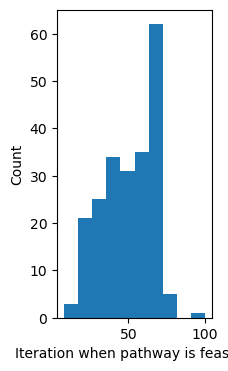

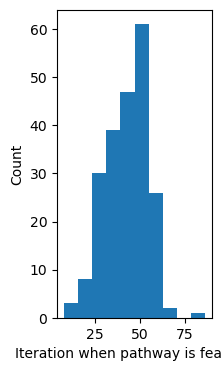

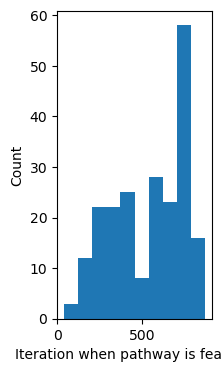

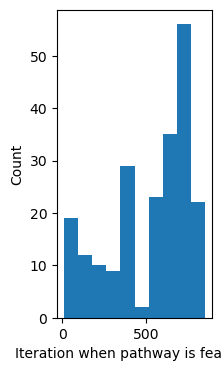

In [121]:
histogram(vanilla_mod2completion_SI_od, x_axis='Iteration when pathway is feasible', y_axis='Count')
histogram(vanilla_mod2completion_80seed, x_axis='Iteration when pathway is feasible', y_axis='Count')
histogram(mean_module_completionNONE, x_axis='Iteration when pathway is feasible', y_axis='Count')
histogram(mean_module_completionC00002, x_axis='Iteration when pathway is feasible', y_axis='Count')

## vanilla fig 3a (sequencial (forward/reverse), mosaic)

In [122]:
def get_kegg_module(module_id):
    url = f"https://rest.kegg.jp/get/{module_id}"
    response = requests.get(url)
    
    if response.status_code == 200:
        return response.text
    else:
        raise Exception(f"Error fetching data from KEGG: {response.status_code}")

def parse_reactions(module_text):
    module_id = re.search(r'ENTRY\s+(\S+)', module_text).group(1)
    reactions_section = re.search(r'REACTION\s+([\s\S]+?)\n[A-Z]', module_text)
    if not reactions_section:
        raise Exception("REACTION section not found")
    
    reactions_lines = reactions_section.group(1).strip().split("\n")
    reactions = []
    for line in reactions_lines:
        line = line.strip()
        reactions.append(re.findall(r'R\d+', line))

    combinations = [{val: idx for idx, val in enumerate(comb)} for comb in product(*reactions)]
    
    return combinations

linear_mod2rns = {}
module_id = "M00006"
module_text = get_kegg_module(module_id)
combos = parse_reactions(module_text)
for i,combo in enumerate(combos):
    linear_mod2rns[f'{module_id}_v{i}'] = combo

print(linear_mod2rns)

{'M00006_v0': {'R02736': 0, 'R02035': 1, 'R01528': 2}, 'M00006_v1': {'R02736': 0, 'R02035': 1, 'R10221': 2}, 'M00006_v2': {'R10907': 0, 'R02035': 1, 'R01528': 2}, 'M00006_v3': {'R10907': 0, 'R02035': 1, 'R10221': 2}}


In [123]:
# from vanilla SI TableS10

linear_mods = set([
'M00006',
'M00008',
'M00013',
'M00015',
'M00018',
'M00018',
'M00021',
'M00023',
'M00023',
'M00024',
'M00025',
'M00025',
'M00027',
'M00027',
'M00027',
'M00027',
'M00028',
'M00032',
'M00032',
'M00037',
'M00038',
'M00040',
'M00040',
'M00042',
'M00042',
'M00047',
'M00052',
'M00052',
'M00066',
'M00091',
'M00113',
'M00131',
'M00132',
'M00134',
'M00135',
'M00135',
'M00136',
'M00136',
'M00138',
'M00169',
'M00174',
'M00176',
'M00358',
'M00418',
'M00422',
'M00422',
'M00525',
'M00525',
'M00527',
'M00527',
'M00528',
'M00531',
'M00531',
'M00531',
'M00533',
'M00535',
'M00538',
'M00554',
'M00555',
'M00555',
'M00568',
'M00579',
'M00624',
'M00630',
'M00630',
'M00631',
'M00632',
'M00661',
'M00674',
'M00675',
'M00741',
'M00775',
'M00794',
'M00794',
'M00795',
'M00796',
'M00798',
'M00801',
'M00802',
'M00804',
'M00829',
'M00830',
'M00836',
'M00844',
'M00845',
'M00847',
'M00848',
'M00848',
'M00848',
'M00848',
'M00875',
'M00876',
'M00877',
'M00879',
'M00882',
'M00883',
'M00890',
'M00891',
'M00901',
'M00910',
'M00910',
'M00918',
'M00919',
'M00923',
'M00934'
])
len(linear_mods)

81

In [124]:
linear_mod2rns = {}
for module_id in linear_mods:
    module_text = get_kegg_module(module_id)
    combos = parse_reactions(module_text)
    for i,combo in enumerate(combos):
        linear_mod2rns[f'{module_id}_v{i}'] = combo
len(linear_mod2rns)

149

In [125]:
linear_mod2rns

{'M00021_v0': {'R00586': 0, 'R00897': 1},
 'M00013_v0': {'R04432': 0,
  'R03045': 1,
  'R03158': 2,
  'R01608': 3,
  'R00705': 4},
 'M00013_v1': {'R04432': 0,
  'R03045': 1,
  'R03158': 2,
  'R01608': 3,
  'R00706': 4},
 'M00013_v2': {'R12356': 0,
  'R03045': 1,
  'R03158': 2,
  'R01608': 3,
  'R00705': 4},
 'M00013_v3': {'R12356': 0,
  'R03045': 1,
  'R03158': 2,
  'R01608': 3,
  'R00706': 4},
 'M00042_v0': {'R00731': 0, 'R02080': 1, 'R02535': 2, 'R02533': 3},
 'M00042_v1': {'R01815': 0, 'R02080': 1, 'R02535': 2, 'R02533': 3},
 'M00028_v0': {'R00259': 0,
  'R02649': 1,
  'R03443': 2,
  'R02283': 3,
  'R00669': 4},
 'M00028_v1': {'R00259': 0,
  'R02649': 1,
  'R03443': 2,
  'R02283': 3,
  'R02282': 4},
 'M00882_v0': {'R12428': 0, 'R12424': 1},
 'M00919_v0': {'R09800': 0, 'R09801': 1, 'R06977': 2, 'R09805': 3},
 'M00113_v0': {'R07869': 0,
  'R07863': 1,
  'R03402': 2,
  'R03401': 3,
  'R07887': 4,
  'R07888': 5,
  'R07889': 6,
  'R07891': 7,
  'R07892': 8,
  'R07893': 9,
  'R07895': 10,

In [126]:
# any reaction out of scope?
result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-09-27_13-49-38_no_lookahead_preExpansion_C00002_37860.pkl.gz')
rns_scope_versionless = set(get_versionless_reactions(result.rns_folditer.keys()))
print(len(rns_scope_versionless))

remove_mods = set()
for mod, rn2order in linear_mod2rns.items():
    for rn, order in rn2order.items():
        if rn not in rns_scope_versionless:
            remove_mods.add(mod)
print(remove_mods)

# remove them
for mod in remove_mods:
    linear_mod2rns.pop(mod)
len(linear_mod2rns)

6677
{'M00134_v1', 'M00032_v1', 'M00032_v5', 'M00032_v0', 'M00032_v4', 'M00032_v3', 'M00032_v2'}


142

In [127]:
vanilla_rn_iteration_dict_versionless = {}
for rn, iter in vanilla.scope.rn_iteration_dict.items():
    rn_less = get_versionless_reaction(rn)
    if rn_less not in vanilla_rn_iteration_dict_versionless:
        vanilla_rn_iteration_dict_versionless[rn_less] = iter
    else:
        if iter < vanilla_rn_iteration_dict_versionless[rn_less]:
            print('updated')
            vanilla_rn_iteration_dict_versionless[rn_less] = iter  # update if lower

In [128]:
linear_mod2rns_od = dict(sorted(linear_mod2rns.items(), key=lambda item: item[0]))

In [129]:
for mod in linear_mod2rns_od:
    print(mod, spearman(linear_mod2rns[mod], vanilla_rn_iteration_dict_versionless))

M00006_v0 (0.0, '1.00E+00')
M00006_v1 (-0.8660254037844387, '3.33E-01')
M00006_v2 (0.8660254037844387, '3.33E-01')
M00006_v3 (nan, 'NAN')
M00008_v0 (-1.0, '0.00E+00')
M00013_v0 (-0.8207826816681233, '8.86E-02')
M00013_v1 (-0.8207826816681233, '8.86E-02')
M00013_v2 (-0.8207826816681233, '8.86E-02')
M00013_v3 (-0.8207826816681233, '8.86E-02')
M00015_v0 (0.9486832980505139, '5.13E-02')
M00018_v0 (0.9486832980505138, '1.38E-02')
M00018_v1 (0.9486832980505138, '1.38E-02')
M00021_v0 (-0.9999999999999999, 'NAN')
M00023_v0 (0.9746794344808964, '4.82E-03')
M00023_v1 (0.9746794344808964, '4.82E-03')
M00024_v0 (1.0, '0.00E+00')
M00025_v0 (1.0, '0.00E+00')
M00025_v1 (1.0, '0.00E+00')
M00027_v0 (1.0, '0.00E+00')
M00027_v1 (1.0, '0.00E+00')
M00027_v2 (1.0, '0.00E+00')
M00027_v3 (1.0, '0.00E+00')
M00028_v0 (-0.9746794344808964, '4.82E-03')
M00028_v1 (-0.9486832980505138, '1.38E-02')
M00037_v0 (1.0, '0.00E+00')
M00038_v0 (0.8183170883849715, '2.44E-02')
M00040_v0 (1.0, '0.00E+00')
M00040_v1 (1.0, '0.0

/Users/tseamuscorlett/Desktop/LongoLab/projects/networkExpansion/utils.py:87: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = spearmanr(data1, data2)


M00531_v6 (-0.9999999999999999, 'NAN')
M00531_v7 (-0.9999999999999999, 'NAN')
M00531_v8 (-0.9999999999999999, 'NAN')
M00531_v9 (nan, 'NAN')
M00533_v0 (-0.9999999999999999, '1.40E-24')
M00535_v0 (-0.19999999999999998, '8.00E-01')
M00538_v0 (-1.0, '0.00E+00')
M00554_v0 (0.9999999999999999, 'NAN')
M00555_v0 (-0.9999999999999999, 'NAN')
M00555_v1 (-0.9999999999999999, 'NAN')
M00555_v10 (-0.9999999999999999, 'NAN')
M00555_v11 (nan, 'NAN')
M00555_v12 (-0.9999999999999999, 'NAN')
M00555_v13 (-0.9999999999999999, 'NAN')
M00555_v14 (nan, 'NAN')
M00555_v2 (0.9999999999999999, 'NAN')
M00555_v3 (nan, 'NAN')
M00555_v4 (nan, 'NAN')
M00555_v5 (0.9999999999999999, 'NAN')
M00555_v6 (nan, 'NAN')
M00555_v7 (nan, 'NAN')
M00555_v8 (0.9999999999999999, 'NAN')
M00555_v9 (-0.9999999999999999, 'NAN')
M00568_v0 (-1.0, '0.00E+00')
M00579_v0 (-0.9999999999999999, 'NAN')
M00624_v0 (0.9999999999999999, 'NAN')
M00630_v0 (-0.8944271909999159, '1.06E-01')
M00630_v1 (-0.8944271909999159, '1.06E-01')
M00631_v0 (-0.89442

In [130]:
# (nan, 'NAN') when all reactions discovered at the same iter

for rn in linear_mod2rns_od['M00006_v3']:
    print(rn, vanilla_rn_iteration_dict_versionless[rn])

R10907 24
R02035 24
R10221 24


In [131]:
# (float, 'NAN') when module has only 2 reactions

for rn in linear_mod2rns_od['M00066_v0']:
    print(rn, vanilla_rn_iteration_dict_versionless[rn])
for rn in linear_mod2rns_od['M00021_v0']:
    print(rn, vanilla_rn_iteration_dict_versionless[rn])

R01497 79
R03354 80
R00586 49
R00897 11


In [132]:
linear_mod2rns['M00008_v0']

{'R02736': 0, 'R02035': 1, 'R02036': 2, 'R05605': 3}

In [133]:
for rn in linear_mod2rns['M00008_v0'].keys():
    print(rn, vanilla_rn_iteration_dict_versionless[rn])

R02736 25
R02035 24
R02036 23
R05605 7


### check linearity

In [134]:
for rn in linear_mod2rns['M00923_v0']:
    print(rn, vanilla_rn_iteration_dict_versionless[rn])

R09697 40
R12553 42
R12552 42
R10676 43
R12584 44


In [135]:
linear_mod2rns['M00923_v0']

{'R09697': 0, 'R12553': 1, 'R12552': 2, 'R10676': 3, 'R12584': 4}

In [136]:
spearman(linear_mod2rns['M00923_v0'], vanilla_rn_iteration_dict_versionless)

(0.9746794344808964, '4.82E-03')

In [137]:
print(rn2eqn['R12553'], rn2rev['R12553'])
print(rn2eqn['R12552'], rn2rev['R12552'])

C20769 => C19823 True
C20768 + C00006 => C20769 + C00005 + C00080 True


In [138]:
vanilla.scope.cpd_iteration_dict['C20769'], vanilla.scope.cpd_iteration_dict['C19823']

(41, 40)

In [139]:
vanilla.scope.cpd_iteration_dict['C20768'], vanilla.scope.cpd_iteration_dict['C20769']

(41, 41)

In [140]:
for rn, cpds in rn2cpds.items():
    if 'C20768' in cpds:
        print(vanilla.scope.rn_iteration_dict[rn], rn, rn2eqn[rn], rn2rev[rn])

42 R10665 C19823 + C00005 + C00080 => C20768 + C00006 True
43 R10676 C20774 => C20768 True
42 R12552 C20768 + C00006 => C20769 + C00005 + C00080 True


In [141]:
# R10665 is the culprit... M00923 is not strictly linear!!

In [142]:
for rn, cpds in rn2cpds.items():
    if 'C20769' in cpds:
        print(vanilla.scope.rn_iteration_dict[rn], rn, rn2eqn[rn], rn2rev[rn])

42 R12552 C20768 + C00006 => C20769 + C00005 + C00080 True
42 R12553 C20769 => C19823 True
43 R12604 C22259 + C00006 => C20769 + C00005 + C00080 True


In [143]:
for rn, cpds in rn2cpds.items():
    if 'C19823' in cpds:
        print(vanilla.scope.rn_iteration_dict[rn], rn, rn2eqn[rn])

40 R09697_v1 C00043 + Z00032 => C19823 + C00001 + Z00032
42 R09825_v1 C19823 + C00025 + Z00035 => C19961 + C00026 + Z00035
42 R10665 C19823 + C00005 + C00080 => C20768 + C00006
42 R12553 C20769 => C19823
41 R12554 C04613 => C19823
42 R12606 C22276 + C00026 => C19823 + C00025


In [144]:
# modules with unreachable reactions:

# M00032: 'R01940', 'R02571' (linear)
# M00049: 'R00331', 'R00333' (not linear)

In [145]:
not_linear = []
for mod in linear_mod2rns.keys():
    iters = []
    for rn in linear_mod2rns[mod]:
        if rn not in  ['R01940', 'R02571']:
            iters.append(vanilla_rn_iteration_dict_versionless[rn])
    if len(iters) != len(set(iters)):
        not_linear.append(mod)

In [146]:
len(linear_mod2rns), len(not_linear)

(142, 66)

In [147]:
# not linear

for mod in linear_mod2rns_od:
    if mod in not_linear:
        print(mod, spearman(linear_mod2rns[mod], vanilla_rn_iteration_dict_versionless))

M00006_v0 (0.0, '1.00E+00')
M00006_v1 (-0.8660254037844387, '3.33E-01')
M00006_v2 (0.8660254037844387, '3.33E-01')
M00006_v3 (nan, 'NAN')
M00013_v0 (-0.8207826816681233, '8.86E-02')
M00013_v1 (-0.8207826816681233, '8.86E-02')
M00013_v2 (-0.8207826816681233, '8.86E-02')
M00013_v3 (-0.8207826816681233, '8.86E-02')
M00015_v0 (0.9486832980505139, '5.13E-02')
M00018_v0 (0.9486832980505138, '1.38E-02')
M00018_v1 (0.9486832980505138, '1.38E-02')
M00023_v0 (0.9746794344808964, '4.82E-03')
M00023_v1 (0.9746794344808964, '4.82E-03')
M00028_v0 (-0.9746794344808964, '4.82E-03')
M00028_v1 (-0.9486832980505138, '1.38E-02')
M00038_v0 (0.8183170883849715, '2.44E-02')
M00042_v0 (0.632455532033676, '3.68E-01')
M00042_v1 (0.632455532033676, '3.68E-01')
M00047_v0 (0.9486832980505139, '5.13E-02')
M00113_v0 (0.999106743903916, '2.98E-19')
M00113_v1 (0.999106743903916, '2.98E-19')
M00113_v2 (0.999106743903916, '2.98E-19')
M00113_v3 (0.999106743903916, '2.98E-19')
M00113_v4 (0.999106743903916, '2.98E-19')
M00

In [148]:
# how many unique modules? vanilla=81
len(set([v[:6] for v in not_linear])), len(set([v[:6] for v in linear_mod2rns.keys() if v not in not_linear]))

(34, 49)

In [149]:
# for these modules, some versions have 'rns with same iter' but not all
set([v[:6] for v in not_linear]) & set([v[:6] for v in linear_mod2rns.keys() if v not in not_linear])

{'M00531', 'M00555', 'M00847'}

M00008_v0 (-1.0, '0.00E+00')
M00021_v0 (-0.9999999999999999, 'NAN')
M00024_v0 (1.0, '0.00E+00')
M00025_v0 (1.0, '0.00E+00')
M00025_v1 (1.0, '0.00E+00')
M00027_v0 (1.0, '0.00E+00')
M00027_v1 (1.0, '0.00E+00')
M00027_v2 (1.0, '0.00E+00')
M00027_v3 (1.0, '0.00E+00')
M00037_v0 (1.0, '0.00E+00')
M00040_v0 (1.0, '0.00E+00')
M00040_v1 (1.0, '0.00E+00')
M00052_v0 (1.0, '0.00E+00')
M00052_v1 (1.0, '0.00E+00')
M00066_v0 (0.9999999999999999, 'NAN')
M00091_v0 (1.0, '0.00E+00')
M00132_v0 (1.0, '0.00E+00')
M00134_v0 (-0.9999999999999999, 'NAN')
M00135_v0 (-0.7999999999999999, '2.00E-01')
M00135_v1 (-0.7999999999999999, '2.00E-01')
M00136_v0 (-0.7999999999999999, '2.00E-01')
M00136_v1 (-0.7999999999999999, '2.00E-01')
M00169_v0 (-0.9999999999999999, 'NAN')
M00174_v0 (-0.9999999999999999, 'NAN')
M00174_v1 (-0.9999999999999999, 'NAN')
M00422_v0 (0.9999999999999999, 'NAN')
M00422_v1 (0.9999999999999999, 'NAN')
M00528_v0 (-0.9999999999999999, 'NAN')
M00531_v0 (-0.9999999999999999, 'NAN')
M00531_v1 (-0.99

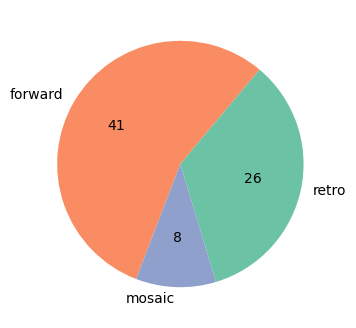

In [150]:
# linear (76 versions, 49 unique)

emergence2mods = {'forward':[], 'mosaic':[], 'retro':[]}
for mod in linear_mod2rns_od:
    if mod not in not_linear:
        c_p = spearman(linear_mod2rns[mod], vanilla_rn_iteration_dict_versionless)
        print(mod, c_p)
        if c_p[0] > 0.9999999:
            emergence2mods['forward'].append(mod)
        elif c_p[0] < -0.9999999:
            emergence2mods['retro'].append(mod)
        else:
            emergence2mods['mosaic'].append(mod)

labels = emergence2mods.keys()
sizes = [len(v) for v in emergence2mods.values()]
colors = ['#f98c62','#8ea0cb', '#6bc2a5']

# Create pie chart
plt.figure(figsize=(4, 4))
# plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.pie(sizes, labels=labels, autopct=lambda p: f'{int(p * sum(sizes) / 100)}', colors=colors, startangle=50)

plt.show()

M00006_v0 (0.0, '1.00E+00')
M00006_v1 (-0.8660254037844387, '3.33E-01')
M00006_v2 (0.8660254037844387, '3.33E-01')
M00006_v3 (nan, 'NAN')
M00008_v0 (-1.0, '0.00E+00')
M00013_v0 (-0.8207826816681233, '8.86E-02')
M00013_v1 (-0.8207826816681233, '8.86E-02')
M00013_v2 (-0.8207826816681233, '8.86E-02')
M00013_v3 (-0.8207826816681233, '8.86E-02')
M00015_v0 (0.9486832980505139, '5.13E-02')
M00018_v0 (0.9486832980505138, '1.38E-02')
M00018_v1 (0.9486832980505138, '1.38E-02')
M00021_v0 (-0.9999999999999999, 'NAN')
M00023_v0 (0.9746794344808964, '4.82E-03')
M00023_v1 (0.9746794344808964, '4.82E-03')
M00024_v0 (1.0, '0.00E+00')
M00025_v0 (1.0, '0.00E+00')
M00025_v1 (1.0, '0.00E+00')
M00027_v0 (1.0, '0.00E+00')
M00027_v1 (1.0, '0.00E+00')
M00027_v2 (1.0, '0.00E+00')
M00027_v3 (1.0, '0.00E+00')
M00028_v0 (-0.9746794344808964, '4.82E-03')
M00028_v1 (-0.9486832980505138, '1.38E-02')
M00037_v0 (1.0, '0.00E+00')
M00038_v0 (0.8183170883849715, '2.44E-02')
M00040_v0 (1.0, '0.00E+00')
M00040_v1 (1.0, '0.0

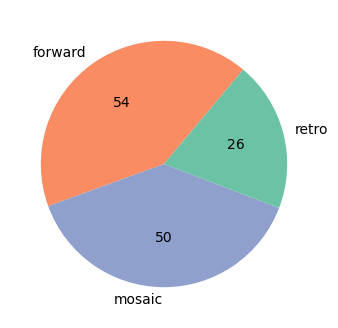

In [151]:
# include non-linear

emergence2mods = {'forward':[], 'mosaic':[], 'retro':[]}
for mod in linear_mod2rns_od:
    c_p = spearman(linear_mod2rns[mod], vanilla_rn_iteration_dict_versionless)
    print(mod, c_p)

    # # strict
    # if math.isnan(c_p[0]):
    #     continue
    # if c_p[0] > 0.9999999:
    #     emergence2mods['forward'].append(mod)
    # elif c_p[0] < -0.9999999:
    #     emergence2mods['retro'].append(mod)
    # else:
    #     emergence2mods['mosaic'].append(mod)

    # loose
    if math.isnan(c_p[0]):
        continue
    if c_p[0] > 0.99:
        emergence2mods['forward'].append(mod)
    elif c_p[0] < -0.99:
        emergence2mods['retro'].append(mod)
    else:
        emergence2mods['mosaic'].append(mod)

labels = emergence2mods.keys()
sizes = [len(v) for v in emergence2mods.values()]
colors = ['#f98c62','#8ea0cb', '#6bc2a5']

# Create pie chart
plt.figure(figsize=(4, 4))
# plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.pie(sizes, labels=labels, autopct=lambda p: f'{int(p * sum(sizes) / 100)}', colors=colors, startangle=50)

plt.show()

In [152]:
mod2count = {}
for k in linear_mod2rns_od.keys():
    c_p = spearman(linear_mod2rns[k], vanilla_rn_iteration_dict_versionless)
    if not math.isnan(c_p[0]):
        if k[:6] not in mod2count:
            mod2count[k[:6]] = 1
        else:
            mod2count[k[:6]] += 1

In [153]:
sum(mod2count.values())

132

In [154]:
vl = [
'M00006',
'M00008',
'M00013',
'M00015',
'M00018',
'M00018',
'M00021',
'M00023',
'M00023',
'M00024',
'M00025',
'M00025',
'M00027',
'M00027',
'M00027',
'M00027',
'M00028',
'M00032',
'M00032',
'M00037',
'M00038',
'M00040',
'M00040',
'M00042',
'M00042',
'M00047',
'M00052',
'M00052',
'M00066',
'M00091',
'M00113',
'M00131',
'M00132',
'M00134',
'M00135',
'M00135',
'M00136',
'M00136',
'M00138',
'M00169',
'M00174',
'M00176',
'M00358',
'M00418',
'M00422',
'M00422',
'M00525',
'M00525',
'M00527',
'M00527',
'M00528',
'M00531',
'M00531',
'M00531',
'M00533',
'M00535',
'M00538',
'M00554',
'M00555',
'M00555',
'M00568',
'M00579',
'M00624',
'M00630',
'M00630',
'M00631',
'M00632',
'M00661',
'M00674',
'M00675',
'M00741',
'M00775',
'M00794',
'M00794',
'M00795',
'M00796',
'M00798',
'M00801',
'M00802',
'M00804',
'M00829',
'M00830',
'M00836',
'M00844',
'M00845',
'M00847',
'M00848',
'M00848',
'M00848',
'M00848',
'M00875',
'M00876',
'M00877',
'M00879',
'M00882',
'M00883',
'M00890',
'M00891',
'M00901',
'M00910',
'M00910',
'M00918',
'M00919',
'M00923',
'M00934'
]

for m in set(vl):
    print(m, vl.count(m), mod2count.get(m, 'n/a'))

M00021 1 1
M00013 1 4
M00042 2 2
M00028 1 2
M00882 1 1
M00919 1 1
M00113 1 8
M00901 1 1
M00132 1 1
M00875 1 1
M00136 2 2
M00422 2 2
M00018 2 2
M00527 2 2
M00579 1 1
M00047 1 1
M00910 2 2
M00027 4 4
M00836 1 1
M00531 3 9
M00775 1 1
M00174 1 2
M00890 1 1
M00554 1 1
M00918 1 1
M00538 1 1
M00176 1 2
M00535 1 1
M00418 1 1
M00134 1 1
M00674 1 1
M00830 1 1
M00024 1 1
M00829 1 1
M00844 1 1
M00794 2 2
M00798 1 1
M00025 2 2
M00845 1 1
M00066 1 1
M00934 1 1
M00038 1 1
M00568 1 1
M00876 1 1
M00015 1 1
M00848 4 4
M00528 1 1
M00631 1 1
M00358 1 1
M00555 2 9
M00795 1 1
M00632 1 1
M00037 1 1
M00135 2 2
M00138 1 1
M00006 1 3
M00923 1 1
M00169 1 1
M00879 1 1
M00630 2 2
M00533 1 1
M00883 1 1
M00032 2 n/a
M00802 1 1
M00040 2 2
M00847 1 2
M00801 1 1
M00023 2 2
M00877 1 1
M00675 1 1
M00741 1 1
M00796 1 1
M00624 1 1
M00525 2 2
M00661 1 1
M00804 1 1
M00052 2 2
M00008 1 1
M00891 1 1
M00091 1 1
M00131 1 1


In [155]:
len(linear_mod2rns_od)

142

In [156]:
diff = ['M00531', 'M00555', 'M00113']
len({k:v for k,v in linear_mod2rns_od.items() if k[:6] not in diff})

107

In [157]:
def absolute_value(val):
    total = sum(sizes)
    return f'{int(round(val * total / 100.0))}'  # Rounds properly

M00006_v0 (0.0, '1.00E+00')
M00006_v1 (-0.8660254037844387, '3.33E-01')
M00006_v2 (0.8660254037844387, '3.33E-01')
M00006_v3 (nan, 'NAN')
M00008_v0 (-1.0, '0.00E+00')
M00013_v0 (-0.8207826816681233, '8.86E-02')
M00013_v1 (-0.8207826816681233, '8.86E-02')
M00013_v2 (-0.8207826816681233, '8.86E-02')
M00013_v3 (-0.8207826816681233, '8.86E-02')
M00015_v0 (0.9486832980505139, '5.13E-02')
M00018_v0 (0.9486832980505138, '1.38E-02')
M00018_v1 (0.9486832980505138, '1.38E-02')
M00021_v0 (-0.9999999999999999, 'NAN')
M00023_v0 (0.9746794344808964, '4.82E-03')
M00023_v1 (0.9746794344808964, '4.82E-03')
M00024_v0 (1.0, '0.00E+00')
M00025_v0 (1.0, '0.00E+00')
M00025_v1 (1.0, '0.00E+00')
M00027_v0 (1.0, '0.00E+00')
M00027_v1 (1.0, '0.00E+00')
M00027_v2 (1.0, '0.00E+00')
M00027_v3 (1.0, '0.00E+00')
M00028_v0 (-0.9746794344808964, '4.82E-03')
M00028_v1 (-0.9486832980505138, '1.38E-02')
M00037_v0 (1.0, '0.00E+00')
M00038_v0 (0.8183170883849715, '2.44E-02')
M00040_v0 (1.0, '0.00E+00')
M00040_v1 (1.0, '0.0

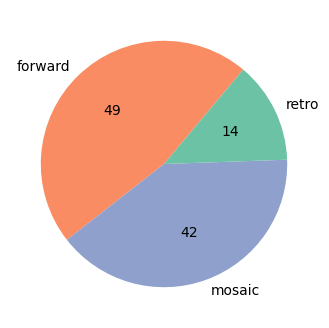

['M00006_v3']


In [158]:
# include non-linear but exclude 'diff' = high deviation in #versions compared to vanilla SI (KEGG updated?)
# also exclude nan modules (['M00006_v3', 'M00066_v0'])

diff = ['M00531', 'M00555', 'M00113']
nan = []
mod2spearman = {}

emergence2mods = {'forward':[], 'mosaic':[], 'retro':[]}
for mod in linear_mod2rns_od:
    if mod[:6] not in diff:
        c_p = spearman(linear_mod2rns[mod], vanilla_rn_iteration_dict_versionless)
        print(mod, c_p)
        mod2spearman[mod] = c_p[0]
    
        # strict
        # if math.isnan(c_p[0]):
        #     continue
        # if c_p[0] > 0.9999999:
        #     emergence2mods['forward'].append(mod)
        # elif c_p[0] < -0.9999999:
        #     emergence2mods['retro'].append(mod)
        # else:
        #     emergence2mods['mosaic'].append(mod)
    
        # # loose
        if math.isnan(c_p[0]):
            nan.append(mod)
            continue
        if c_p[0] > 0.95:
            emergence2mods['forward'].append(mod)
        elif c_p[0] < -0.95:
            emergence2mods['retro'].append(mod)
        else:
            emergence2mods['mosaic'].append(mod)

for e, mods in emergence2mods.items():
    emergence2mods[e] = set(mods) - set(['M00006_v3', 'M00066_v0'])

labels = emergence2mods.keys()
sizes = [len(v) for v in emergence2mods.values()]
colors = ['#f98c62','#8ea0cb', '#6bc2a5']


# Create pie chart
plt.figure(figsize=(4, 4))
# plt.pie(sizes, labels=labels, colors=colors, startangle=140)
# plt.pie(sizes, labels=labels, autopct=lambda p: f'{int(p * sum(sizes) / 100)}', colors=colors, startangle=50)
plt.pie(sizes, labels=labels, autopct=absolute_value, colors=colors, startangle=50)

# plt.savefig(f'pathway_emergence_vanilla.svg', dpi=300, bbox_inches='tight')
plt.show()
print(nan)

In [159]:
len(emergence2mods['mosaic']), len(emergence2mods['retro']), len(emergence2mods['forward'])

(42, 14, 49)

In [160]:
len(emergence2mods['mosaic']) + len(emergence2mods['retro']) + len(emergence2mods['forward'])

105

### now, try with enzyme-gated

In [161]:
rn2foMean_C00002 = {}
for rn in df_rns_cumiter_C00002.index:
    foMean = np.mean(df_rns_cumiter_C00002.loc[rn])
    
    # versionless
    if rn[:6] not in rn2foMean_C00002:
        rn2foMean_C00002[rn[:6]] = foMean
    else:
        # update if faster
        if foMean < rn2foMean_C00002[rn[:6]]:
            rn2foMean_C00002[rn[:6]] = foMean

M00006_v0 (0.5, '6.67E-01')
M00006_v1 (0.5, '6.67E-01')
M00006_v2 (0.5, '6.67E-01')
M00006_v3 (0.5, '6.67E-01')
M00008_v0 (-0.9486832980505139, '5.13E-02')
M00013_v0 (-0.9746794344808964, '4.82E-03')
M00013_v1 (-0.9746794344808964, '4.82E-03')
M00013_v2 (-0.9746794344808964, '4.82E-03')
M00013_v3 (-0.9746794344808964, '4.82E-03')
M00015_v0 (-0.316227766016838, '6.84E-01')
M00018_v0 (-0.8720815992723809, '5.39E-02')
M00018_v1 (-0.8720815992723809, '5.39E-02')
M00021_v0 (-0.9999999999999999, 'NAN')
M00023_v0 (0.9999999999999999, '1.40E-24')
M00023_v1 (0.9999999999999999, '1.40E-24')
M00024_v0 (1.0, '0.00E+00')
M00025_v0 (1.0, '0.00E+00')
M00025_v1 (1.0, '0.00E+00')
M00027_v0 (-0.8660254037844387, '3.33E-01')
M00027_v1 (-0.8660254037844387, '3.33E-01')
M00027_v2 (-0.8660254037844387, '3.33E-01')
M00027_v3 (-0.8660254037844387, '3.33E-01')
M00028_v0 (0.9746794344808964, '4.82E-03')
M00028_v1 (0.9746794344808964, '4.82E-03')
M00037_v0 (1.0, '0.00E+00')
M00038_v0 (-0.5, '2.53E-01')
M00040_v0

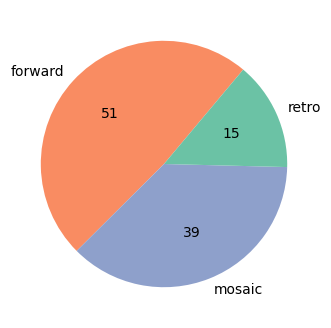

['M00066_v0']


In [162]:
# include non-linear but exclude 'diff' = high deviation in #versions
diff = ['M00531', 'M00555', 'M00113']
nan = []

mod2spearman_foldGated = {}
emergence2mods_foldGated = {'forward':[], 'mosaic':[], 'retro':[]}
for mod in linear_mod2rns_od:
    if mod[:6] not in diff:
        c_p = spearman(linear_mod2rns[mod], rn2foMean_C00002)
        print(mod, c_p)
        mod2spearman_foldGated[mod] = c_p[0]
    
        # strict
        # if math.isnan(c_p[0]):
        #     continue
        # if c_p[0] > 0.9999999:
        #     emergence2mods_foldGated['forward'].append(mod)
        # elif c_p[0] < -0.9999999:
        #     emergence2mods_foldGated['retro'].append(mod)
        # else:
        #     emergence2mods_foldGated['mosaic'].append(mod)
    
        # # loose
        if math.isnan(c_p[0]):
            nan.append(mod)
            continue
        elif c_p[0] > 0.95:
            emergence2mods_foldGated['forward'].append(mod)
        elif c_p[0] < -0.95:
            emergence2mods_foldGated['retro'].append(mod)
        else:
            emergence2mods_foldGated['mosaic'].append(mod)

for e, mods in emergence2mods_foldGated.items():
    emergence2mods_foldGated[e] = set(mods) - set(['M00006_v3', 'M00066_v0'])

labels = emergence2mods_foldGated.keys()
sizes = [len(v) for v in emergence2mods_foldGated.values()]
colors = ['#f98c62','#8ea0cb', '#6bc2a5']

# Create pie chart
plt.figure(figsize=(4, 4))
# plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
# plt.pie(sizes, labels=labels, autopct=lambda p: f'{int(p * sum(sizes) / 100)}', colors=colors, startangle=50)
plt.pie(sizes, labels=labels, autopct=absolute_value, colors=colors, startangle=50)

# plt.savefig(f'pathway_emergence_foldGated.svg', dpi=300, bbox_inches='tight')
plt.show()
print(nan)

In [163]:
len(emergence2mods_foldGated['mosaic']), len(emergence2mods_foldGated['retro']), len(emergence2mods_foldGated['forward'])

(39, 15, 51)

In [164]:
len(emergence2mods_foldGated['mosaic']) + len(emergence2mods_foldGated['retro']) + len(emergence2mods_foldGated['forward'])

105

In [165]:
# similar proportions, but modules did move categories

In [166]:
print(set(emergence2mods['forward']) - set(emergence2mods_foldGated['forward']))
print(set(emergence2mods_foldGated['forward']) - set(emergence2mods['forward']))

{'M00027_v3', 'M00027_v0', 'M00027_v1', 'M00027_v2', 'M00847_v1', 'M00875_v0'}
{'M00910_v0', 'M00047_v0', 'M00910_v1', 'M00028_v1', 'M00138_v0', 'M00845_v0', 'M00028_v0', 'M00169_v0'}


In [167]:
print(set(emergence2mods['retro']) - set(emergence2mods_foldGated['retro']))
print(set(emergence2mods_foldGated['retro']) - set(emergence2mods['retro']))

{'M00533_v0', 'M00879_v0', 'M00008_v0', 'M00028_v0', 'M00169_v0'}
{'M00804_v0', 'M00013_v0', 'M00847_v0', 'M00013_v2', 'M00013_v3', 'M00013_v1'}


In [168]:
print(set(emergence2mods['mosaic']) - set(emergence2mods_foldGated['mosaic']))
print(set(emergence2mods_foldGated['mosaic']) - set(emergence2mods['mosaic']))

{'M00910_v0', 'M00047_v0', 'M00910_v1', 'M00804_v0', 'M00013_v0', 'M00847_v0', 'M00013_v2', 'M00028_v1', 'M00013_v3', 'M00013_v1', 'M00138_v0', 'M00845_v0'}
{'M00533_v0', 'M00879_v0', 'M00027_v3', 'M00027_v0', 'M00027_v1', 'M00027_v2', 'M00847_v1', 'M00875_v0', 'M00008_v0'}


In [169]:
for rn in linear_mod2rns['M00018_v0']:
    print(rn, rn2foMean_C00002[rn])

R00480 86.988
R02291 60.0
R01773 60.0
R01771 43.0
R01466 44.0


# TableS_Pathway_emergence

In [170]:
mod2emergence = {}
mod2emergence_foldGated = {}

for e, mods in emergence2mods.items():
    for mod in mods:
        mod2emergence[mod] = e
for e, mods in emergence2mods_foldGated.items():
    for mod in mods:
        mod2emergence_foldGated[mod] = e

In [171]:
df = pd.DataFrame(columns=['Module ID', 'Reactions', 'Description', 'Spearmen Corr', 'Pathway Type', 'Spearmen Corr_FG', 'Pathway Type_FG'])

data = []
for mod in sorted(mod2emergence.keys(), key=str):
    data.append({
        'Module ID': mod,
        'Reactions': list(linear_mod2rns_od[mod].keys()),
        'Description': module2name[mod[:6]],
        'Spearmen Corr': mod2spearman[mod],
        'Pathway Type': mod2emergence[mod],
        'Spearmen Corr_FG': mod2spearman_foldGated[mod],
        'Pathway Type_FG': mod2emergence_foldGated[mod]
    })

df = pd.DataFrame(data)  # Convert list of dicts to DataFrame
df.head()

,Module ID,Reactions,Description,Spearmen Corr,Pathway Type,Spearmen Corr_FG,Pathway Type_FG
0,M00006_v0,"[R02736, R02035, R01528]","Pentose phosphate pathway, oxidative phase, gl...",0.000000,mosaic,0.500000,mosaic
1,M00006_v1,"[R02736, R02035, R10221]","Pentose phosphate pathway, oxidative phase, gl...",-0.866025,mosaic,0.500000,mosaic
2,M00006_v2,"[R10907, R02035, R01528]","Pentose phosphate pathway, oxidative phase, gl...",0.866025,mosaic,0.500000,mosaic
3,M00008_v0,"[R02736, R02035, R02036, R05605]","Entner-Doudoroff pathway, glucose-6P => glycer...",-1.000000,retro,-0.948683,mosaic
4,M00013_v0,"[R04432, R03045, R03158, R01608, R00705]","Malonate semialdehyde pathway, propanoyl-CoA =...",-0.820783,mosaic,-0.974679,retro


In [172]:
# df.to_csv('TableS_Pathway_emergence.csv', index=False)

# TableS_PDS_Class
Lineage;	PDS (archaea);	PDS (bacteria);	PDS (eukaryotes);	Class;	Metabolic?

In [173]:
x2dsArc = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv')
x2dsBac = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv')
x2dsEuk = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv')

In [174]:
df = pd.DataFrame(columns=['PDS (archaea)', 'PDS (bacteria)', 'PDS (eukaryotes)', 'Class', 'Metabolic?'])
seen = set()

data = []
for x in sorted(x2dsArc.keys(), key=int):
    data.append({
        'Lineage': x,
        'Name': x2name.get(x, 'NO XNAME'),
        'PDS (archaea)': round(x2dsArc[x], 3),
        'PDS (bacteria)': round(x2dsBac[x], 3),
        'PDS (eukaryotes)': round(x2dsEuk[x], 3),
        'Class': x2class[x],
        'Metabolic?': x in x2foMean
    })

df = pd.DataFrame(data)  # Convert list of dicts to DataFrame
df.head()

,Lineage,Name,PDS (archaea),PDS (bacteria),PDS (eukaryotes),Class,Metabolic?
0,1,cradle loop barrel,1.000,1.000,1.000,beta,True
1,2,OB-fold,1.000,1.000,1.000,beta,True
2,4,SH3,1.000,1.000,1.000,beta,True
3,5,beta-propeller-like,0.715,0.986,1.000,beta,True
4,6,NO XNAME,0.009,0.040,0.949,beta,True


In [175]:
# df.to_csv('TableS_PDS_Class.csv', index=False)

# TableS_networkSize

In [176]:
len(x2ns.keys())

396

In [177]:
x2ns_od = dict(sorted(x2ns.items(), key=lambda item: int(item[0])))

data = []
for x in x2ns_od.keys():
    data.append({
        'Lineage': x,
        'Name': x2name.get(x, 'NO XNAME'),
        'Network Size': x2ns_od[x]
    })

df = pd.DataFrame(data)  # Convert list of dicts to DataFrame
df.head()

,Lineage,Name,Network Size
0,1,cradle loop barrel,2257
1,2,OB-fold,4294
2,4,SH3,4291
3,5,beta-propeller-like,4094
4,6,NO XNAME,4293


In [178]:
# df.to_csv('TableS_networkSize.csv', index=False)

# domain accretion

In [179]:
# fastest run
result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-09-27_13-49-38_no_lookahead_preExpansion_C00002_37860.pkl.gz')

## try 'domain composition'

In [180]:
lineage = '2002'
folditer2rules = {}
seen = set()

for rnRule, i in result.rules_folditer.items():
    rn, rule = rnRule[0], rnRule[1]
    if lineage in rule and rule not in seen:
        if i not in folditer2rules.keys():
            folditer2rules[i] = set([rule])
            seen.add(rule)
        else:
            folditer2rules[i].add(rule)
            seen.add(rule)
print(len(seen))

87


In [181]:
# lineage = '2002'
# cumiter2rules = {}
# seen = set()

# for rnRule, i in result.rules_cumiter.items():
#     rn, rule = rnRule[0], rnRule[1]
#     if lineage in rule and rule not in seen:
#         if i not in cumiter2rules.keys():
#             cumiter2rules[i] = set([rule])
#             seen.add(rule)
#         else:
#             cumiter2rules[i].add(rule)
#             seen.add(rule)
# print(len(seen))

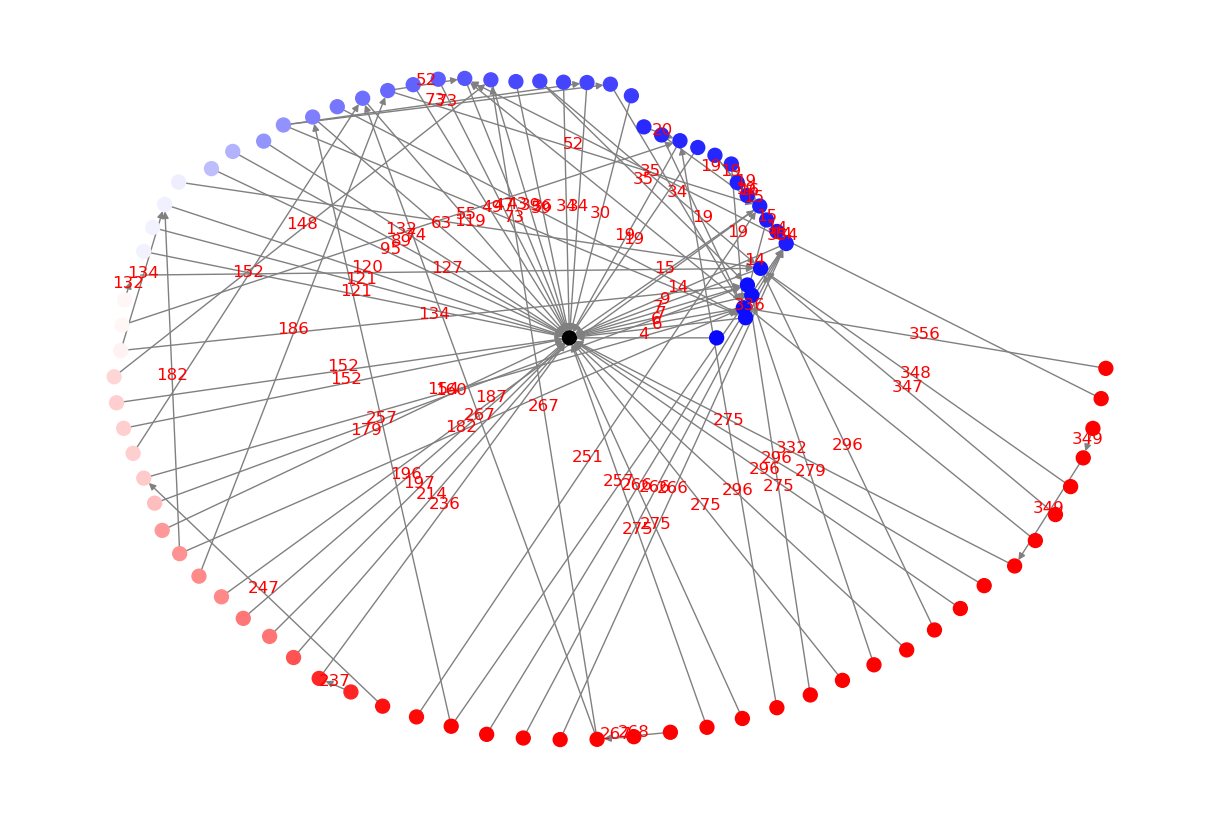

In [182]:
# Input data
data = folditer2rules

# Create graph
G = nx.DiGraph()

# Add edges based on co-occurrence with '2002'
seen = set()
for time, sets in data.items():
    for s in sets:
        subsets = [sub for sub in seen if sub.issubset(s)]
        if len(subsets) != 0:  # ignore first case
            max_len = max([len(sub) for sub in subsets])
            max_subsets = [sub for sub in subsets if len(sub) == max_len]
            # print(time, s, max_subsets)
            
            for max_sub in max_subsets:
                G.add_edge(str(set(s)), str(set(max_sub)), time=time, weight=time)
                # print(len(s), max_sub)
        seen.add(frozenset(s))


# Set node positions using polar coordinates with radius corresponding to 'time'
pos = {}
root = str({lineage})  # Set the root (center) as the lineage
theta_step = 2 * np.pi / len(G.nodes())  # Evenly spaced angles (rad) for nodes

# Set root (center) position
pos[root] = (0, 0)

# Get unique times to scale the radius
times = sorted(set(d['time'] for u, v, d in G.edges(data=True)))
# map to colors
cmap = plt.cm.bwr
time2color = {t: to_hex(cmap(t)) for t in times}

node2time = {}
# Calculate positions for other nodes using polar coordinates
for i, node in enumerate(G.nodes()):
    if node == root:
        # Record the position as separate attributes
        G.nodes[node]['x'] = 0
        G.nodes[node]['y'] = 0
        G.nodes[node]['color'] = 'black'
    else:
        node_time = {d['time'] for u, v, d in G.edges(node, data=True)}
        # node_time = list(node_time)[0]  # stopped working somehow
        node_time = min(node_time)
        node2time[node] = node_time

        # Scale the radius according to time (you can adjust the multiplier)
        # radius = (node_time * 2) + 10 
        radius = np.log(node_time + 1)*50
        # print(node_time, radius, node)
        angle = i * theta_step

        # Convert polar to Cartesian coordinates
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        pos[node] = (x, y)

        # Record the position as separate attributes
        G.nodes[node]['x'] = x
        G.nodes[node]['y'] = y
        G.nodes[node]['color'] = time2color[node_time]

# Get node colors from the graph attributes
node_colors = [G.nodes[n]['color'] for n in G.nodes]

# Draw tree
plt.figure(figsize=(12, 8))
nx.draw(
    G, pos,
    with_labels=False,
    node_color=node_colors,
    node_size=100,
    font_size=12,
    font_weight='bold',
    edge_color='gray'
)

# Annotate edges with 'time' using a custom method to avoid label positioning issues
edge_labels = {(u, v): d['time'] for u, v, d in G.edges(data=True)}

# Manually position edge labels (slightly offset from the edges)
for (u, v), time in edge_labels.items():
    # Get position of both nodes (u, v) and calculate the midpoint
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    label_pos = ((x0 + x1) / 2, (y0 + y1) / 2)
    
    # Draw the edge label at the calculated position
    plt.text(label_pos[0], label_pos[1], str(time), color='red', fontsize=12, ha='center')

plt.show()

# Export to GML with 'x' and 'y' saved separately
# nx.write_gml(G, f"accretion_{lineage}_circle.gml")

In [183]:
# angle by time
layer1_nodes = set()
for edge in G.edges:
    if "{'2002'}" in edge:
        layer1_nodes.add([item for item in edge if item != "{'2002'}"][0])

layer1_nodes_list = [node for node in node2time.keys() if node in layer1_nodes]

layer1_degree_total = 0
for n in layer1_nodes_list:
    layer1_degree_total += G.degree[n]

# big = ["{'2002', '2007'}", #
# "{'2002', '12'}",  #
# "{'2002', '1'}",  #
# "{'2002', '304'}",  # 
# "{'2002', '11'}"  #
# ]

node2angle = {}
# theta = 2*np.pi/(len(layer1_nodes) + 5)
theta = 2*np.pi/(layer1_degree_total)
angle = 0
# for node in layer1_nodes_list:
    # if node in big:
    #     angle += theta * 2
    #     node2angle[node] = angle
    # else:
    #     angle += theta
    #     node2angle[node] = angle
for node in layer1_nodes_list:
    angle += theta * G.degree[node]
    node2angle[node] = angle

In [184]:
layer2_nodes = set()
for edge in G.edges:
    if "{'2002'}" not in edge:
        # layer1_node exists
        if layer1_nodes & set(edge) != set():
            # print(set(edge) - layer1_nodes)
            node1 = list(layer1_nodes & set(edge))[0]
            node2 = list((set(edge) - layer1_nodes))[0]
            layer2_nodes.add(node2)
            node2angle[node2] = node2angle[node1]


layer3_nodes = G.nodes - layer1_nodes - layer2_nodes - set(["{'2002'}"])
for edge in G.edges:
    if layer3_nodes & set(edge) != set():
        node2 = list(layer2_nodes & set(edge))[0]
        node3 = list(set(edge) - layer2_nodes)[0]
        node2angle[node3] = node2angle[node2]

In [185]:
len(G.nodes), len(layer1_nodes), len(layer2_nodes), len(layer3_nodes), len(node2angle)

(87, 40, 39, 7, 86)

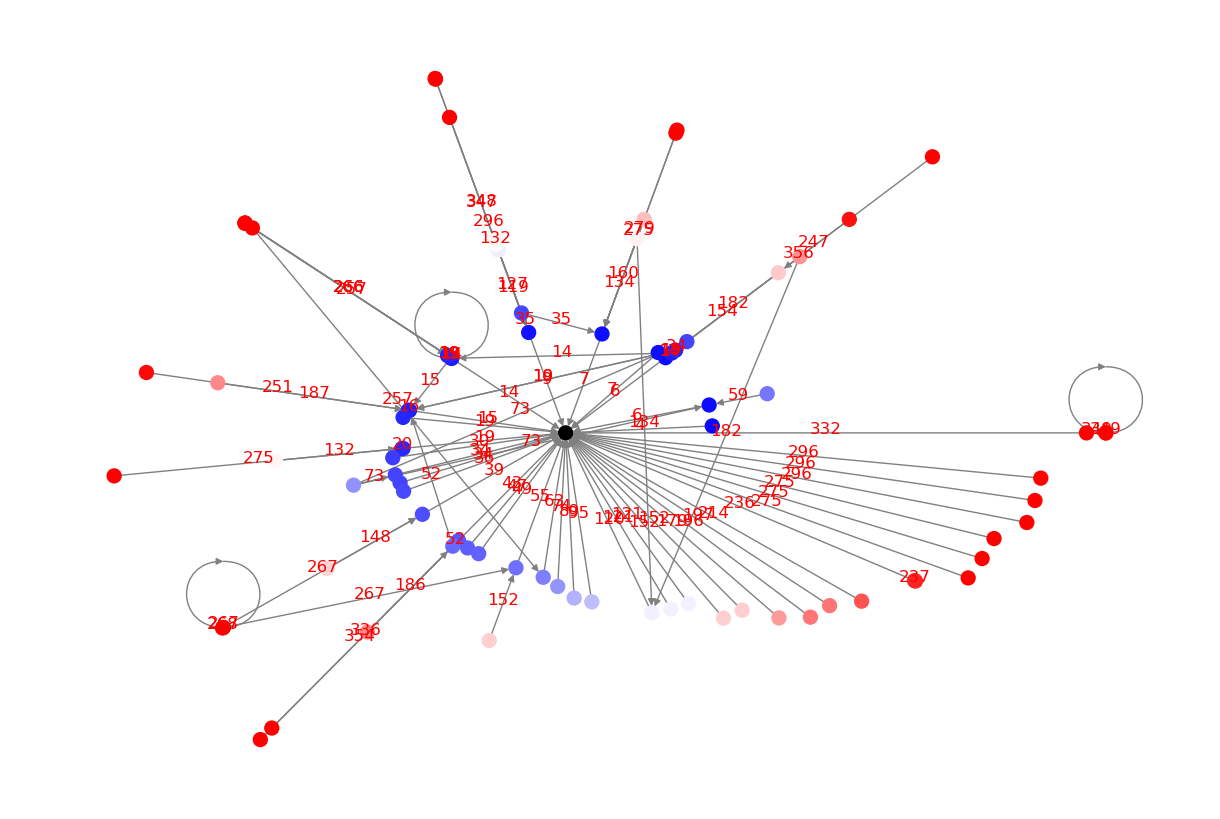

In [186]:
# Input data
data = folditer2rules

# Create graph
G = nx.DiGraph()

# Add edges based on co-occurrence with '2002'
seen = set()
for time, sets in data.items():
    for s in sets:
        subsets = [sub for sub in seen if sub.issubset(s)]
        if len(subsets) != 0:  # ignore first case
            max_len = max([len(sub) for sub in subsets])
            max_subsets = [sub for sub in subsets if len(sub) == max_len]
            # print(time, s, max_subsets)
            
            for max_sub in max_subsets:
                G.add_edge(str(set(s)), str(set(max_sub)), time=time, weight=time)
                # print(len(s), max_sub)
        seen.add(frozenset(s))

# Set root (center) position
pos = {}
root = str({lineage})  # Set the root (center) as the lineage
pos[root] = (0, 0)

# Get unique times to scale the radius
times = sorted(set(d['time'] for u, v, d in G.edges(data=True)))
# map to colors
cmap = plt.cm.bwr
time2color = {t: to_hex(cmap(t)) for t in times}

node2time = {}
# Calculate positions for other nodes using polar coordinates
for i, node in enumerate(G.nodes()):
    if node == root:
        # Record the position as separate attributes
        G.nodes[node]['x'] = 0
        G.nodes[node]['y'] = 0
        G.nodes[node]['color'] = 'black'
        G.nodes[node]['height'] = 10
        G.nodes[node]['width'] = 10
    else:
        node_time = {d['time'] for u, v, d in G.edges(node, data=True)}
        node_time = list(node_time)[0]
        node2time[node] = node_time

        # Scale the radius according to time 
        radius = (node_time*1.2) + 150 
        # radius = np.log(node_time + 1)*50

        # custom angle
        angle = node2angle[node]

        # Convert polar to Cartesian coordinates
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        pos[node] = (x, y)

        # Record the position as separate attributes
        G.nodes[node]['x'] = x
        G.nodes[node]['y'] = y
        G.nodes[node]['color'] = time2color[node_time]
        G.nodes[node]['height'] = 5 * len(eval(node))
        G.nodes[node]['width'] = 5 * len(eval(node))

# Get node colors from the graph attributes
node_colors = [G.nodes[n]['color'] for n in G.nodes]

# Draw tree
plt.figure(figsize=(12, 8))
nx.draw(
    G, pos,
    with_labels=False,
    node_color=node_colors,
    node_size=100,
    font_size=12,
    font_weight='bold',
    edge_color='gray'
)

# Annotate edges with 'time' using a custom method to avoid label positioning issues
edge_labels = {(u, v): d['time'] for u, v, d in G.edges(data=True)}

# Manually position edge labels (slightly offset from the edges)
for (u, v), time in edge_labels.items():
    # Get position of both nodes (u, v) and calculate the midpoint
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    label_pos = ((x0 + x1) / 2, (y0 + y1) / 2)
    
    # Draw the edge label at the calculated position
    plt.text(label_pos[0], label_pos[1], str(time), color='red', fontsize=12, ha='center')

plt.show()

# Export to GML with 'x' and 'y' saved separately
# nx.write_gml(G, f"accretion_{lineage}_circle_time.gml")

## calculate composition-wise PDS

In [187]:
comp2dsArc = csv2dict('../data/domain_accretion_gml_csv/composition2DS_archaea_recovered.csv')
comp2dsBac = csv2dict('../data/domain_accretion_gml_csv/composition2DS_bacteria_recovered.csv')
comp2dsEuk = csv2dict('../data/domain_accretion_gml_csv/composition2DS_eukaryotes_recovered.csv')

In [188]:
comp2dsArc = {eval(k):v for k,v in comp2dsArc.items()}
comp2dsBac = {eval(k):v for k,v in comp2dsBac.items()}
comp2dsEuk = {eval(k):v for k,v in comp2dsEuk.items()}

In [189]:
df = pd.DataFrame({'Composition': comp2dsArc.keys(), 'Arc PDS': comp2dsArc.values(), 'Bac PDS': comp2dsBac.values(), 'Euk PDS': comp2dsEuk.values()})
df.head(20)

,Composition,Arc PDS,Bac PDS,Euk PDS
0,"(222, 3323, 2002, 7581, 304, 3321)",0.00,0.349112,1.000000
1,"(11, 221, 2002)",0.95,1.000000,0.326531
2,"(4223, 2002, 4971, 7595, 4017, 3858)",0.10,0.005917,1.000000
3,"(7521, 2002, 623)",0.00,0.952663,1.000000
4,"(2002, 10)",0.95,1.000000,0.989796
5,"(207, 210, 2002)",1.00,0.000000,0.994898
6,"(304, 2002, 230)",1.00,0.556213,1.000000
7,"(304, 7531, 1, 2002)",0.90,0.994083,1.000000
8,"(306, 75, 2002, 10)",0.45,0.940828,0.994898
9,"(206, 2002)",1.00,1.000000,1.000000


In [190]:
comp2dsArcBac = {}
for comp, ds in comp2dsArc.items():
    comp2dsArcBac[comp] = (comp2dsArc[comp] + comp2dsBac[comp])/2

comp2dsArcBac[frozenset({'2002'})] = 1

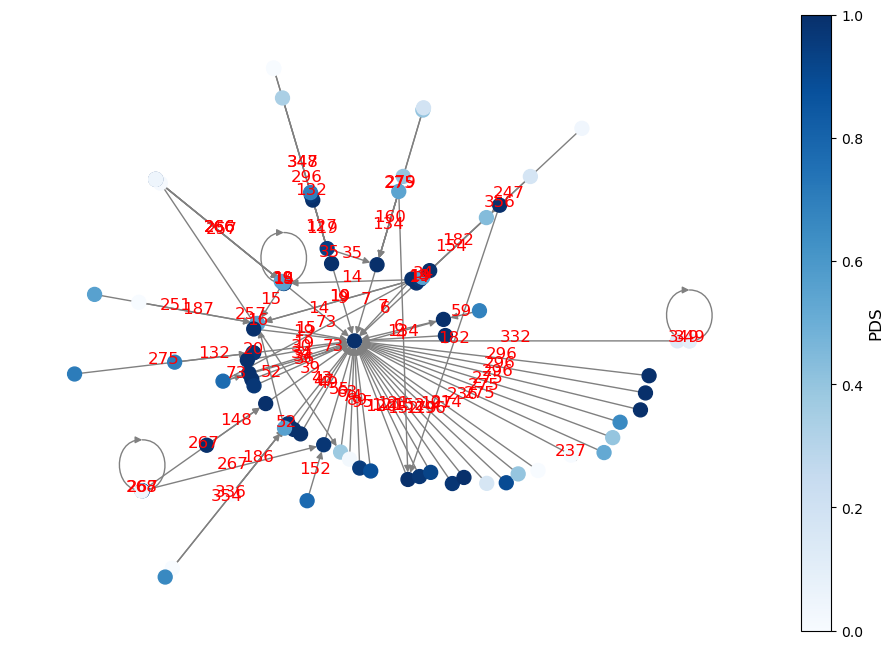

In [191]:
data = folditer2rules

# Create graph
G = nx.DiGraph()

# Add edges based on co-occurrence with '2002'
seen = set()
for time, sets in data.items():
    for s in sets:
        subsets = [sub for sub in seen if sub.issubset(s)]
        if len(subsets) != 0:  # ignore first case
            max_len = max([len(sub) for sub in subsets])
            max_subsets = [sub for sub in subsets if len(sub) == max_len]
            # print(time, s, max_subsets)
            
            for max_sub in max_subsets:
                G.add_edge(str(set(s)), str(set(max_sub)), time=time, weight=time)
                # print(len(s), max_sub)
        seen.add(frozenset(s))

# Set root (center) position
pos = {}
root = str({lineage})  # Set the root (center) as the lineage
pos[root] = (0, 0)

# Get unique times to scale the radius
times = sorted(set(d['time'] for u, v, d in G.edges(data=True)))
# map to colors
# cmap = plt.cm.bwr
# norm = Normalize(vmin=min(times), vmax=max(times))
# time2color = {t: cmap(norm(t)) for t in times}

# Get color
cmap = plt.cm.Blues
# cmap = plt.cm.viridis
dict1 = comp2dsArcBac  # compositional PDS for color
# dict1 = comp2rnNum  # num reactions for color
# dict1 = comp2ns

norm = Normalize(vmin=min(dict1.values()), vmax=max(dict1.values()))
dict2 = {ds: to_hex(cmap(norm(ds))) for ds in dict1.values()}


node2time = {}
# Calculate positions for other nodes using polar coordinates
for i, node in enumerate(G.nodes()):
    if node == root:
        # Record the position as separate attributes
        G.nodes[node]['x'] = 0
        G.nodes[node]['y'] = 0
        G.nodes[node]['color'] = dict2[dict1[frozenset(eval(node))]]
        # G.nodes[node]['color'] = 'black'
        G.nodes[node]['height'] = 10
        G.nodes[node]['width'] = 10
    else:
        node_time = {d['time'] for u, v, d in G.edges(node, data=True)}
        node_time = list(node_time)[0]
        node2time[node] = node_time

        # Scale the radius according to time 
        radius = (node_time*1.2) + 150 
        # radius = np.log(node_time + 1)*50

        # custom angle
        angle = node2angle[node]

        # Convert polar to Cartesian coordinates
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        pos[node] = (x, y)

        # Record the position as separate attributes
        G.nodes[node]['x'] = x
        G.nodes[node]['y'] = y
        G.nodes[node]['color'] = dict2[dict1[frozenset(eval(node))]]
        G.nodes[node]['height'] = 5 * len(eval(node))
        G.nodes[node]['width'] = 5 * len(eval(node))


# Get node colors from the graph attributes
node_colors = [G.nodes[n]['color'] for n in G.nodes]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

# Draw the tree
nx.draw(
    G, pos, ax=ax,
    with_labels=False,
    node_color=node_colors,
    node_size=100,
    font_size=12,
    font_weight='bold',
    edge_color='gray'
)

# Draw edge labels
edge_labels = {(u, v): d['time'] for u, v, d in G.edges(data=True)}
for (u, v), time in edge_labels.items():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    label_pos = ((x0 + x1) / 2, (y0 + y1) / 2)
    ax.text(label_pos[0], label_pos[1], str(time), color='red', fontsize=12, ha='center')

# Add colormap bar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)  # Pass the axis here
cbar.set_label('PDS', fontsize=12)

# plt.savefig(f'accretion_{lineage}_circle_time_compDS.svg', dpi=300, bbox_inches='tight')
plt.show()

# Export to GML with 'x' and 'y' saved separately
# nx.write_gml(G, f"accretion_{lineage}_circle_time_compDS.gml")

# NONE (base seed) discovery order of purine cofactors

In [192]:
df_cpds_cumiter_NONE = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_cumiter_NONE.csv', index_col=0)
df_cpds_folditer_NONE = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_folditer_NONE.csv', index_col=0)

In [193]:
for run in df_cpds_cumiter_NONE.columns:
    if not (df_cpds_cumiter_NONE[run]['C00002'] < df_cpds_cumiter_NONE[run]['C00004'] < df_cpds_cumiter_NONE[run]['C00010']):
        print(run)
# ATP, NAD, CoA

In [194]:
np.mean(df_cpds_folditer_NONE.loc['C00002'])

107.477

# universal lineages

In [195]:
count = 0
for x in x2foMean:
    if x2ds[x] > 0.9999999999:
        # print(x, x2name.get(x,x), x2ds[x], x in group1)
        print(x, x2name.get(x,x), x2foMean[x])
        count += 1
count

2002 TIM beta/alpha-barrel 2.0
2006 HAD domain-like 3.0
2484 Ribonuclease H-like 4.0
2003 Rossmann-like 5.0
2007 Flavodoxin-like 6.0
1 cradle loop barrel 7.0
304 Alpha-beta plaits 9.0
221 beta-Grasp 15.547
2004 P-loop domains-like 18.0
2005 HUP domain-like 19.0
101 HTH 78.262
327 Alpha-lytic protease prodomain-like 88.224
2 OB-fold 103.506
102 HhH/H2TH 223.604
4 SH3 216.766


15

## non-metabolic universals?

In [196]:
nmu = []
for x in x2ds:
    if x not in x2foMean:
        if x2ds[x] > 0.99:
            print(x, x2name.get(x,x), x2ds[x])
            nmu.append(x)

140 140 0.9974898933157661


In [197]:
# X140

# 002664728	e7ap2A2	AUTO_NONREP	140.1.1	7ap2	A	A:634-813	A:635-814	NO_UNP	alpha bundles	
# "NO_X_NAME"	"NO_H_NAME"	"Anticodon-binding domain of a subclass of class I aminoacyl-tRNA synthetases"	F_UNCLASSIFIED	NOT_DOMAIN_ASSEMBLY	RRW

In [198]:
for x in nmu:
    print(x, x2class[x])

140 alpha


# all-beta: Greek key or Jelly roll

In [199]:
for x, cl in x2class.items():
    if cl == 'beta' and x in x2foMean:
        print(x, x2foMean[x], x2name.get(x,x))

1 7.0 cradle loop barrel
2 103.506 OB-fold
220 136.086 PH domain-like
236 20.0 GroES-like
239 93.443 Ribosomal protein L25-like
270 175.127 FMT C-terminal domain-like
4 216.766 SH3
4011 215.904 4011
4028 358.97 4028
4237 227.7 4237
4295 228.082 4295
5084 83.875 Outer membrane meander beta-barrels
7 314.649 7
70 84.433 beta-clip
75 315.598 75
9 310.604 Lipocalins/Streptavidin
4046 364.215 4046
62 103.664 62
64 228.395 WW domain-like
3699 83.993 3699
10 8.0 jelly-roll
11 14.153 Immunoglobulin-like beta-sandwich
12 14.121 Glycosyl hydrolase domain-like
3156 281.143 Cupredoxin-like
319 228.09 HSP20-like
3249 314.653 3249
4004 55.486 4004
4081 85.393 4081
4178 175.077 4178
65 64.499 65
66 317.866 66
73 285.166 73
1143 253.056 1143
1144 259.044 1144
207 128.394 Single-stranded right-handed beta-helix
208 59.972 Single-stranded left-handed beta-helix
5 28.51 beta-propeller-like
6 326.878 6
702 366.888 702
4052 267.495 4052
4160 339.134 4160
4161 320.174 4161
69 291.143 69
708 227.893 708
865 

# Did oxygen introduce new collaboration between lineages?

In [200]:
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
rn2rules_scope = pd.read_pickle('../data/assets/rn2rules_scope.pkl')

In [201]:
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')
x2arc = csv2dict('../data/assets/xgroup2/xgroup2architecture.csv')

# preATP 1000 runs

df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)
df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_folditer_preATP.csv', index_col=0)
df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_folditer_preATP.csv', index_col=0)

In [202]:
rns_scope = set(rn2rules_scope.keys())
len(rns_scope)

5730

In [203]:
rn2cpds = csv2dict('../data/assets/rn2cpds_SI.csv')
rns_ox = [k for k,v in rn2cpds.items() if 'C00007' in v and k in rns_scope]
len(rns_ox)

# direct O2 rns; what about including indirect?

630

In [204]:
run = '37860'  # fastest
df_rules_folditer[run]

('R04446', frozenset({'spontaneous'}))                          1
('R11100_v1', frozenset({'spontaneous'}))                       1
('R08637', frozenset({'spontaneous'}))                          1
('R12185', frozenset({'spontaneous'}))                          1
('R06982_v1', frozenset({'spontaneous'}))                       1
                                                             ... 
('R00089_v3', frozenset({'4054', '4036', '4035', '2498'}))    371
('R00434_v1', frozenset({'4054', '4036', '4035', '2498'}))    371
('R00434_v3', frozenset({'4054', '4036', '4035', '2498'}))    371
('R00434_v2', frozenset({'4054', '4036', '4035', '2498'}))    371
('R00089_v1', frozenset({'4054', '4036', '4035', '2498'}))    371
Name: 37860, Length: 7558, dtype: int64

In [205]:
iter2rules = {}

for rnRule, i in df_rules_folditer[run].items():
    rule = eval(rnRule)[1]
    
    if i not in iter2rules:
        iter2rules[i] = [rule]
    else:
        iter2rules[i].append(rule)

iter2rules_unique = {}
for k,v in iter2rules.items():
    iter2rules_unique[k] = [frozenset(t) for t in set(tuple(lst) for lst in v)]

In [206]:
iter2rules_unique[18]

[frozenset({'2004', '7525'}),
 frozenset({'7525'}),
 frozenset({'2004'}),
 frozenset({'2003'}),
 frozenset({'304'}),
 frozenset({'2484'}),
 frozenset({'2004', '2484'})]

In [207]:
# check new rules

seen = set()
iter2new_rules = {}
for k, v in iter2rules_unique.items():
    new_rules = []
    for rule in v:
        if rule not in seen:
            new_rules.append(rule)
            seen.add(rule)
    iter2new_rules[k] = new_rules
iter2new_rules[18]           

[frozenset({'2004', '7525'}), frozenset({'2004'}), frozenset({'2004', '2484'})]

### check if rn uses oxygen

In [208]:
iter2rnRules = {}

for rnRule, i in df_rules_folditer[run].items():

    if i not in iter2rnRules:
        iter2rnRules[i] = [eval(rnRule)]
    else:
        iter2rnRules[i].append(eval(rnRule))

In [209]:
iter2rnRules[1]

[('R04446', frozenset({'spontaneous'})),
 ('R11100_v1', frozenset({'spontaneous'})),
 ('R08637', frozenset({'spontaneous'})),
 ('R12185', frozenset({'spontaneous'})),
 ('R06982_v1', frozenset({'spontaneous'})),
 ('R07316', frozenset({'spontaneous'})),
 ('R11098_v1', frozenset({'spontaneous'})),
 ('R03128', frozenset({'spontaneous'})),
 ('R11098_v2', frozenset({'spontaneous'})),
 ('R08698', frozenset({'spontaneous'})),
 ('R11099_v1', frozenset({'spontaneous'})),
 ('R11101_v1', frozenset({'spontaneous'})),
 ('R01390', frozenset({'spontaneous'})),
 ('R01652_v1', frozenset({'spontaneous'})),
 ('R11099_v2', frozenset({'spontaneous'})),
 ('R11100_v2', frozenset({'spontaneous'})),
 ('R11101_v2', frozenset({'spontaneous'}))]

In [210]:
seen = set()
iter2new_rules_bool = {}

for i, rnRules in iter2rnRules.items():
    new_rules = []
    for rnRule in rnRules:
        rn = rnRule[0]
        rule = rnRule[1]  
        
        if rule not in seen:
            new_rules.append((rule, rn in rns_ox))  # save new rule with 'ox or not' boolean annotation
            seen.add(rule)
    iter2new_rules_bool[i] = new_rules
iter2new_rules_bool[300] 

[(frozenset({'5', '914'}), True)]

In [211]:
iter2new_rules_ox = {}
iter2new_rules_nox = {}

for i, values in iter2new_rules_bool.items():
    for new_rule_bool in values:
        new_rule, bool = new_rule_bool[0], new_rule_bool[1]
        if bool:  # ox reaction
            if i not in iter2new_rules_ox:
                iter2new_rules_ox[i] = [new_rule]
            else:
                iter2new_rules_ox[i].append(new_rule)
        else:  # NOT ox reaction
            if i not in iter2new_rules_nox:
                iter2new_rules_nox[i] = [new_rule]
            else:
                iter2new_rules_nox[i].append(new_rule)

## # New rules

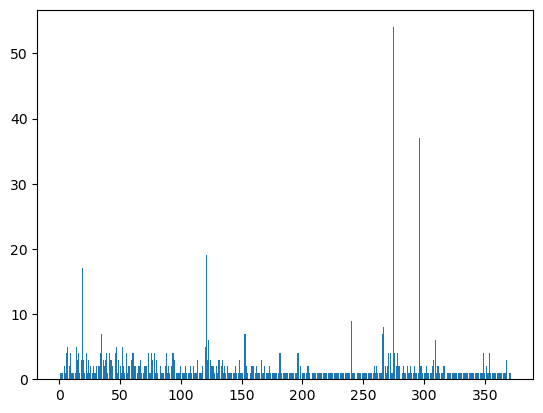

In [212]:
iter2new_rulesNum = {k:len(v) for k,v in iter2new_rules.items()}
iter2new_rulesNum_od = dict(sorted(iter2new_rulesNum.items(), key=lambda item: item[0]))  # must be ordered
# plt.plot(iter2new_rulesNum_od.values())
plt.bar(iter2new_rulesNum_od.keys(), iter2new_rulesNum_od.values())
plt.show()

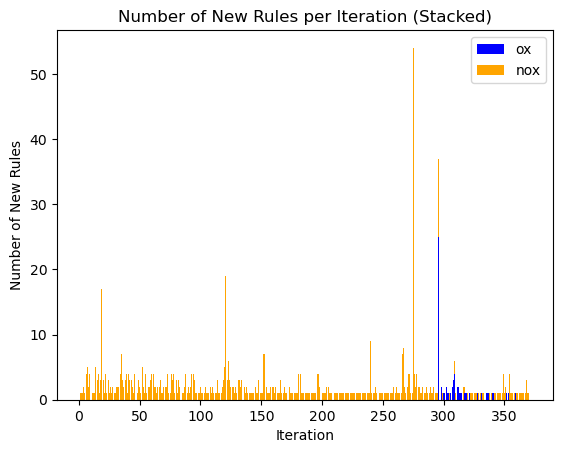

In [213]:
iter2new_rulesNum_ox = {k: len(v) for k, v in iter2new_rules_ox.items()}
iter2new_rulesNum_ox_od = dict(sorted(iter2new_rulesNum_ox.items(), key=lambda item: item[0]))

iter2new_rulesNum_nox = {k: len(v) for k, v in iter2new_rules_nox.items()}
iter2new_rulesNum_nox_od = dict(sorted(iter2new_rulesNum_nox.items(), key=lambda item: item[0]))

# Get the full range of iteration keys
all_iterations = sorted(set(iter2new_rulesNum_ox_od.keys()) | set(iter2new_rulesNum_nox_od.keys()))

# Get values, defaulting to 0 if a key is missing in one of the categories
values_ox = [iter2new_rulesNum_ox_od.get(k, 0) for k in all_iterations]
values_nox = [iter2new_rulesNum_nox_od.get(k, 0) for k in all_iterations]

# Plot stacked bar chart
plt.bar(all_iterations, values_ox, label="ox", color="blue")
plt.bar(all_iterations, values_nox, bottom=values_ox, label="nox", color="orange")

# Labels and title
plt.xlabel("Iteration")
plt.ylabel("Number of New Rules")
plt.title("Number of New Rules per Iteration (Stacked)")
plt.legend()

plt.show()

In [214]:
# what are the big peaks?

folditer2cpd = {}
for c, order in df_cpds_folditer[run].items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)

folditer2folds = {}
for fold, folditer in df_folds_folditer[run].items():
    if folditer not in folditer2folds.keys():
        folditer2folds[folditer] = [fold]
    else:
        folditer2folds[folditer].append(fold)

for k,v in iter2new_rulesNum.items():
    if v > 10:
        print(k,v, folditer2folds[k])

# HUP => CoA / NAD
# 2492 => FAD / FMN
# triplet => Arg / protein
# chlorophyll synth => O2

19 17 ['2005']
121 19 ['2492']
275 54 ['602', '4953']
296 37 ['3997']


## # New connections
new associations between previously unassociated domains? 
(i.e., two domains that were never co-domaisn before became co-domains 
in order to catalyze oxygen related reaction or a reaction downstream of that)

In [215]:
iter2new_rules_od = dict(sorted(iter2new_rules.items(), key=lambda item: item[0]))

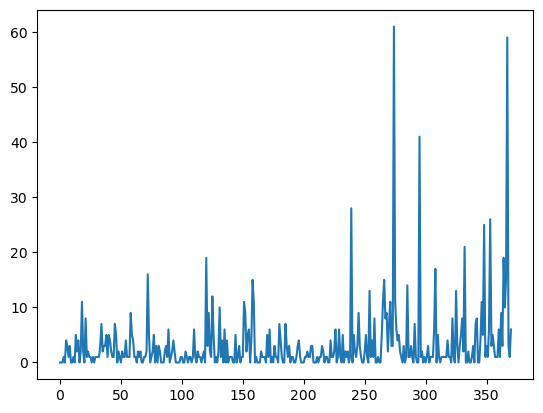

In [216]:
# Track previously seen associations
seen_associations = set()
new_associations_by_step = {}

for step, rules in iter2new_rules_od.items():
    new_associations = 0
    
    for rule in rules:
        # Generate all pairwise associations within the frozenset
        pairs = {frozenset({a, b}) for a in rule for b in rule if a != b}
        
        # Count new associations
        for pair in pairs:
            if pair not in seen_associations:
                new_associations += 1
                seen_associations.add(pair)
    
    # Save the count of new associations for this step
    new_associations_by_step[step] = new_associations

plt.plot(new_associations_by_step.values())
plt.show()

In [217]:
for k,v in new_associations_by_step.items():
    if v > 20:
        print(k,v, folditer2folds[k])

240 28 ['4011']
275 61 ['602', '4953']
296 41 ['3997']
333 21 ['3697']
349 25 ['4223', '4971']
354 26 ['306', '75']
368 59 ['3579']


In [218]:
iter2new_rules_od[368]

[frozenset({'2007',
            '205',
            '244',
            '3281',
            '3456',
            '3579',
            '3843',
            '4025',
            '4272'}),
 frozenset({'3281', '3456', '3579', '3843'}),
 frozenset({'1001',
            '2003',
            '2007',
            '205',
            '221',
            '244',
            '2485',
            '3281',
            '3456',
            '3579',
            '3697',
            '3843',
            '4025',
            '4272',
            '4335',
            '5100',
            '633'})]

In [219]:
x2rn['3579']

['R11945_v1', 'R11945_v2']

In [220]:
# single reaction led to 59 'new associations' being discovered
# overall, more 'new associations' at later iterations => because of oxygen, or just time?

rn2rules['R11945_v1']

{frozenset({'3281', '3456', '3579', '3843'}),
 frozenset({'2007',
            '205',
            '244',
            '3281',
            '3456',
            '3579',
            '3843',
            '4025',
            '4272'}),
 frozenset({'1001',
            '2003',
            '2007',
            '205',
            '221',
            '244',
            '2485',
            '3281',
            '3456',
            '3579',
            '3697',
            '3843',
            '4025',
            '4272',
            '4335',
            '5100',
            '633'})}

### now differentiate ox vs. nox

In [221]:
iter2new_rules_bool_od = dict(sorted(iter2new_rules_bool.items(), key=lambda item: item[0]))

In [222]:
iter2new_rules_bool_od[8]

[(frozenset({'10'}), False), (frozenset({'10', '2007'}), False)]

In [223]:
# Track previously seen associations
seen_associations = set()
iter2new_associations_nox = {}
iter2new_associations_ox = {}

for i, rules in iter2new_rules_bool_od.items():
    new_associations_nox = 0
    new_associations_ox = 0
    
    for rule_bool in rules:
        rule, bool = rule_bool[0], rule_bool[1]
        
        # Generate all pairwise associations within the frozenset
        pairs = {frozenset({a, b}) for a in rule for b in rule if a != b}
        
        # Count new associations
        for pair in pairs:
            if pair not in seen_associations:
                if bool:  # oxygen
                    new_associations_ox += 1
                    seen_associations.add(pair)
                else:  # not oxygen
                    new_associations_nox += 1
                    seen_associations.add(pair)
                        
    # Save the count of new associations for this step
    iter2new_associations_nox[i] = new_associations_nox
    iter2new_associations_ox[i] = new_associations_ox

In [224]:
iter2new_associations_nox.keys() == iter2new_associations_ox.keys()

True

In [225]:
len(iter2new_associations_nox.values()), len(iter2new_associations_ox.values())

(371, 371)

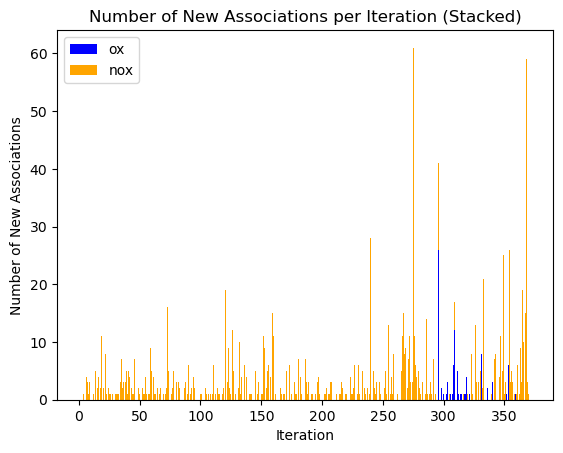

In [226]:
# Ensure all iteration keys are included (union of keys from both dicts)
all_iterations = sorted(set(iter2new_associations_ox.keys()) | set(iter2new_associations_nox.keys()))

# Get values with default of 0 if key is missing
values_ox = [iter2new_associations_ox.get(k, 0) for k in all_iterations]
values_nox = [iter2new_associations_nox.get(k, 0) for k in all_iterations]

# Plot stacked bar chart
plt.bar(all_iterations, values_ox, label="ox", color="blue")
plt.bar(all_iterations, values_nox, bottom=values_ox, label="nox", color="orange")

# Labels and title
plt.xlabel("Iteration")
plt.ylabel("Number of New Associations")
plt.title("Number of New Associations per Iteration (Stacked)")
plt.legend()

plt.show()
